# Fractional Brownian Motion Using Variance Ratio Tests

Consider a sample of $t$ measurements,

$
\begin{align}
X_0, X_1, X_2, \ldots, X_t
\end{align}
\tag{1}
$

A test is desired to determine if the series represents brownian motion, which is defined by,

$
\begin{align}
X_t = \sum_{i=1}^t X_i - X_{i-1} = \sum_{i=1}^t \Delta X_{i}
\end{align}
\tag{2}
$

where $\Delta X_i$ are independent and identically distributed with distribution,

$
\begin{align}
\Delta X_i \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{3}
$

and

$
\begin{align}
\text{Cov}(\Delta X_i \Delta X_j) = \sigma^2 \delta_{ij}
\end{align}
\tag{4}
$

This is the homoscedasticity assumption. Consider the difference,

$
\begin{align}
\Delta X_i(s) = X_i - X_{i+s}
\end{align}
\tag{5}
$

So that,

$
\begin{align}
X_t = \sum_{i=1}^n \Delta X_i(s)
\end{align}
\tag{6}
$

with $t=ns$. Let, 

$
\begin{align}
\sigma^2(s) = \text{Var}\left(\Delta X_i (s) \right)
\end{align}
\tag{7}
$

Recall for brownian motion $\sigma_B^2(t) = \sigma^2t$, it follows that $\sigma^2_B(s) = \sigma^2(1)s$. Consider the ratio,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
\tag{8}
$

where,

$
\begin{align}
&\sigma^2(1) = \frac{1}{t-1} \sum_{i=1}^t \left(X_i - X_{i-1} - \mu \right) \\
&\mu = \frac{1}{t} \left( X_t - X_0 \right)
\end{align}
\tag{9}
$

In Lo and Mackinlay, 1988, "Stock market Prices do not Follow Random Walks" it was shown that an unbiased estimator of $\sigma^2(s)$ is given by,

$
\begin{align}
\sigma^2(s) = \frac{1}{m} \sum_{i=s}^t \left( X_t - X_{t-s} - s\mu \right)^2
\end{align}
\tag{10}
$

where,

$
\begin{align}
m = \left(t - s + 1 \right) \left( 1 - \frac{s}{t} \right)
\end{align}
\tag{11}
$

If $X_t$ is brownian motion, $\sigma^2(s) = \sigma^2(1)$, $s = \sigma^2_B(s)$. It follows that $\text{VR}(s) = 1$. A test statistic for this condition is given by,

$
\begin{align}
Z(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta(s)}}
\end{align}
\tag{12}
$

where,

$
\begin{align}
\theta(s) = \frac{2\left( 2s - 1 \right)\left( s - 1 \right)}{3st}
\end{align}
\tag{13}
$

and $Z(s) \sim \text{Normal}(0,1)$. This test-statistic was derived assuming homoscedasticity which implies that the random component is independent of $s$. If instead the random component varies with $s$ heteroscedasticity is assumed.

For this case the test-statistic is given by,

$
\begin{align}
Z^\ast(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta^\ast (s)}}
\end{align}
\tag{14}
$

where,

$
\begin{align}
&\theta^\ast (s) = \sum_{j=1}^{s-1} \left[ \frac{2\left( s - j \right) } {s} \right]^2 \hat{\delta}(j) \\
&\hat{\delta}(j) = \frac{\sum_{i=j+1}^t \left( X_i - X_{i-1} - \mu \right)^2 \left( X_{i-j} - X_{i-j-1} - \mu \right)^2}{\left[ \sum_{i=1}^t \left( X_i - X_{i-1} - \mu \right)^2 \right]^2}
\end{align}
\tag{15}
$

The significance test using $Z(s)$ and $Z^\ast(s)$ succeeds if the time series is brownian motion. This test is implemented using two tails and the series is brownian motion if it succeeds. A test for $H<0.5$ uses a lower tail test and succeeds if the test for brownian motion fails. Similarly, A test for $H>0.5$ would use an upper tail test and succeed if the test for brownian motion fails.

## Import

In [126]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats, HypothesisTestType
from lib.plots import fpoints, comparison, curve, variance_ratio_test, PlotType
from lib.utils import create_parameter_scan, apply_to_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [127]:
def create(H_vals, npts):
    params = [{"H": H, "npts": npts} for H in H_vals]
    source = lambda **kwargs: fbm.create_fft_source(**kwargs)
    return create_parameter_scan(source, *params)

def lag_var_plot(samples, H, npts):
    title = f"Simulated FBM Lagged Variance: H={H}"
    labels = [r"$\sigma^2(s)$", r"$s^{2H}$"]
    s_vals, lag_var = stats.compute_lag_var(samples, smax=npts/10, npts=100)
    t, fbm_var = fbm.compute_var(numpy.array(s_vals)[::5], H=H)
    fpoints(data=lag_var, func=fbm_var, x=s_vals, fx=t, plot_axis_type=PlotType.LOG, title=title, labels=labels, xlabel=r"$s$", ylabel=r"$\sigma^2(s)$")

def vr_plot(samples, H, npts):
    title = f"Simulated FBM Variance Ratio: H={H}"
    labels = [r"VR$(s)$", r"$s^{2H-1}$"]
    s_vals, vr = fbm.compute_vr_scan(samples, smax=npts/10, npts=100)
    t, fbm_vr = fbm.compute_vr(numpy.array(s_vals)[::5], H=H)
    fpoints(data=vr, func=fbm_vr, x=s_vals, fx=t, title=title, labels=labels, plot_axis_type=PlotType.LOG, xlabel=r"$s$", ylabel=r"VR$(s)$")
    
def homo_test_stat_plot(report, H):
    title = f"Homoscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)

def hetero_test_stat_plot(report, H):
    title = f"Heteroscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)
    
def H_labels(H_vals):
    return [f"H={format(H, '1.2f')}" for H in H_vals]

## $\sigma^2 (s)$ and $\text{VR}(s)$ Verification

The $\sigma^2 (s)$ calculation is verified by comparing with $s^{2H}$. The variance ratio is given by,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
$

Since $\sigma^2(s) \sim s^{2H}$ and $\sigma_B^2(s) \sim s$ it follows that $\text{VR}(s) \sim s^{2H - 1}$.

In [128]:
npts = 2**16
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

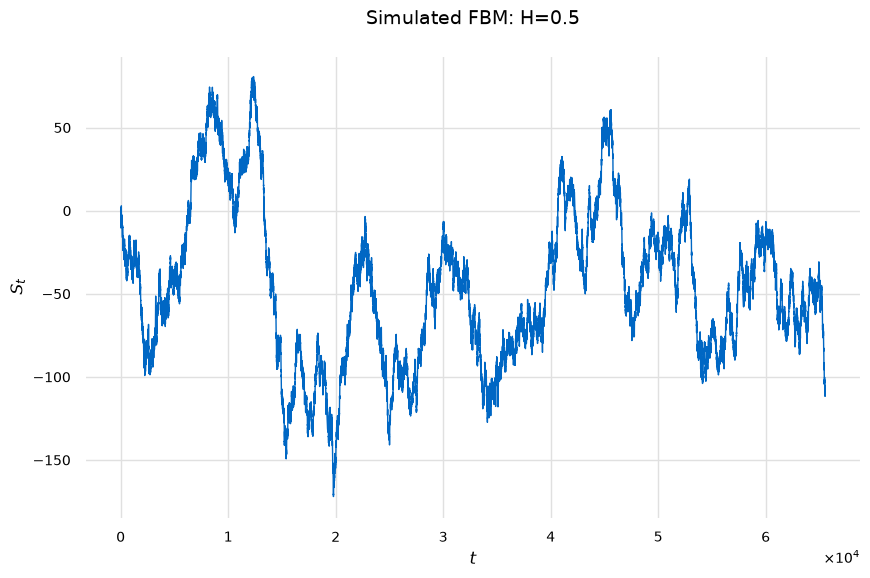

In [129]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

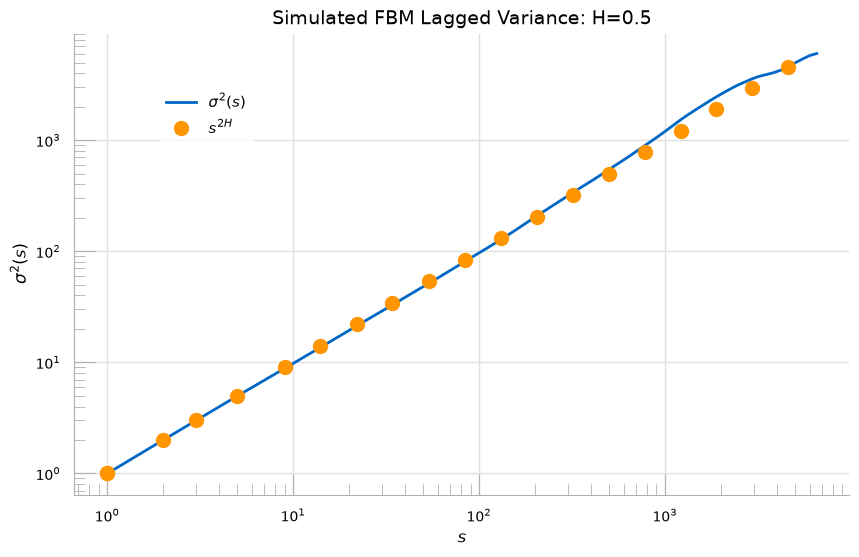

In [130]:
lag_var_plot(samples[0], H_vals[0], npts)

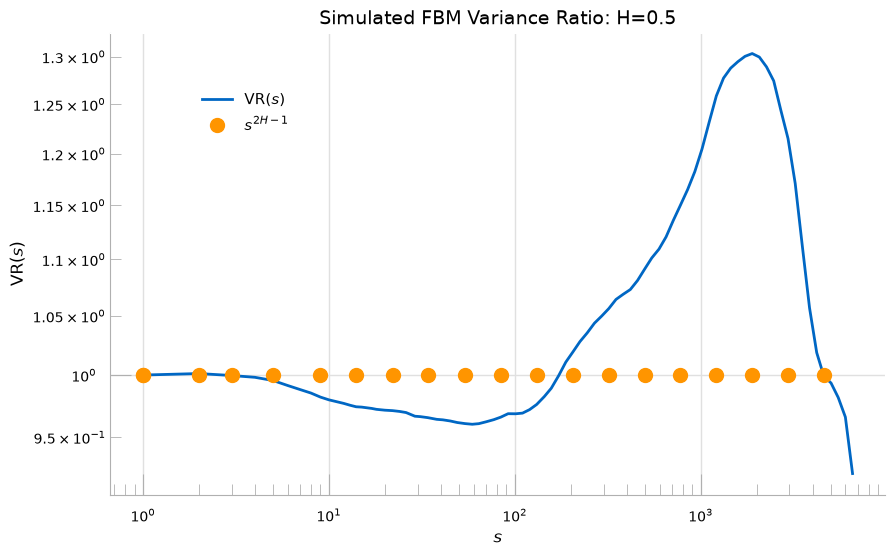

In [131]:
vr_plot(samples[0], H_vals[0], npts)

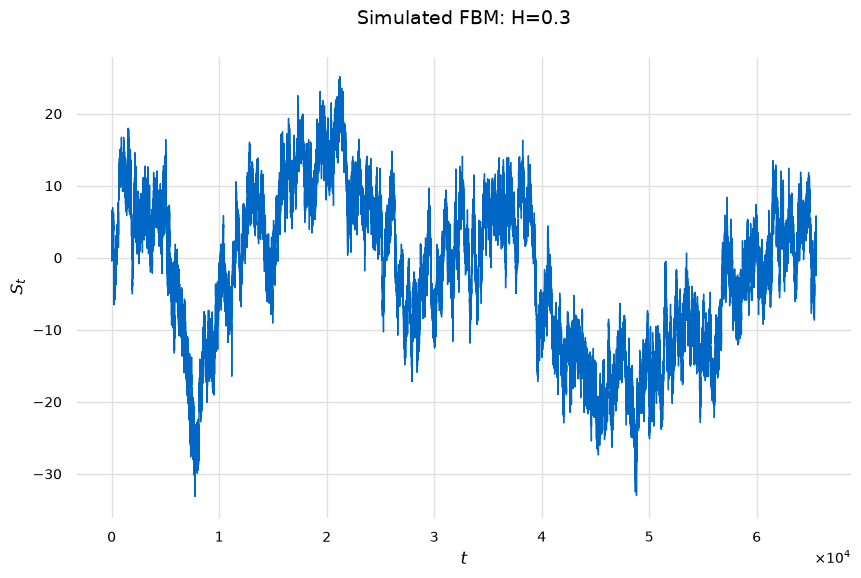

In [132]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

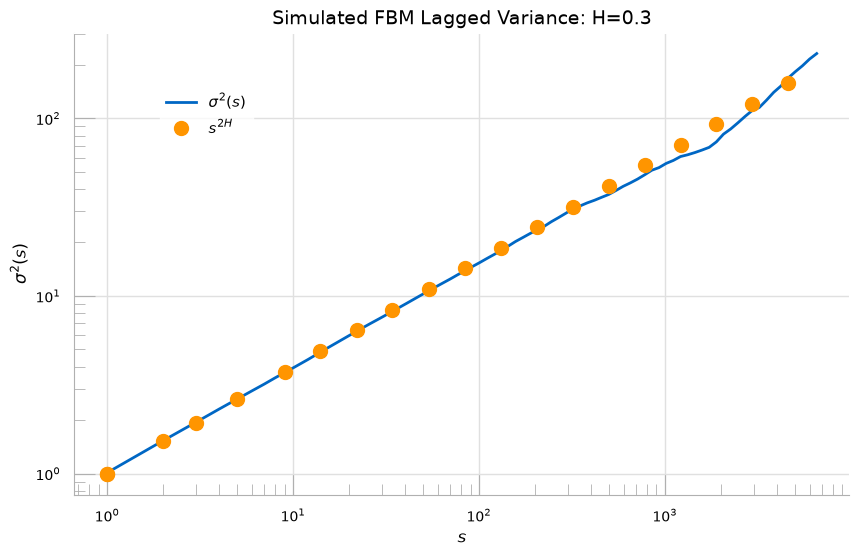

In [133]:
lag_var_plot(samples[1], H_vals[1], npts)

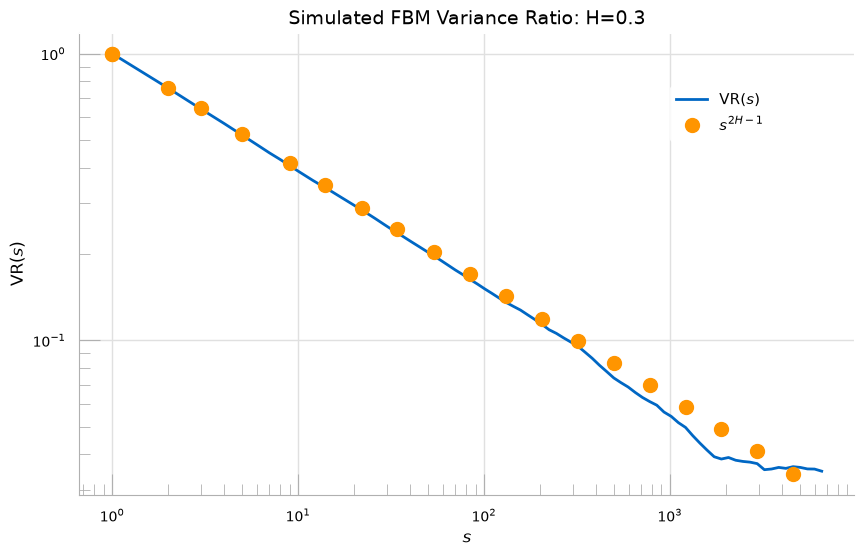

In [134]:
vr_plot(samples[1], H_vals[1], npts)

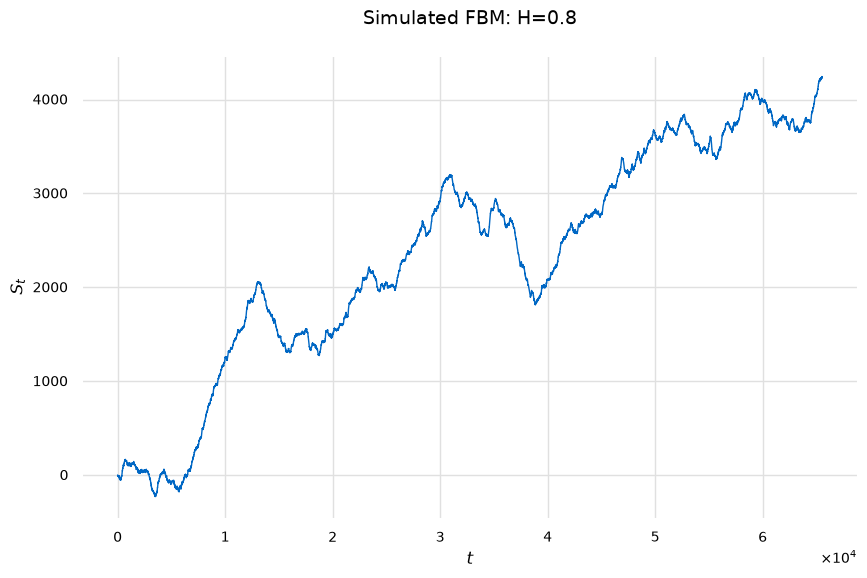

In [135]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

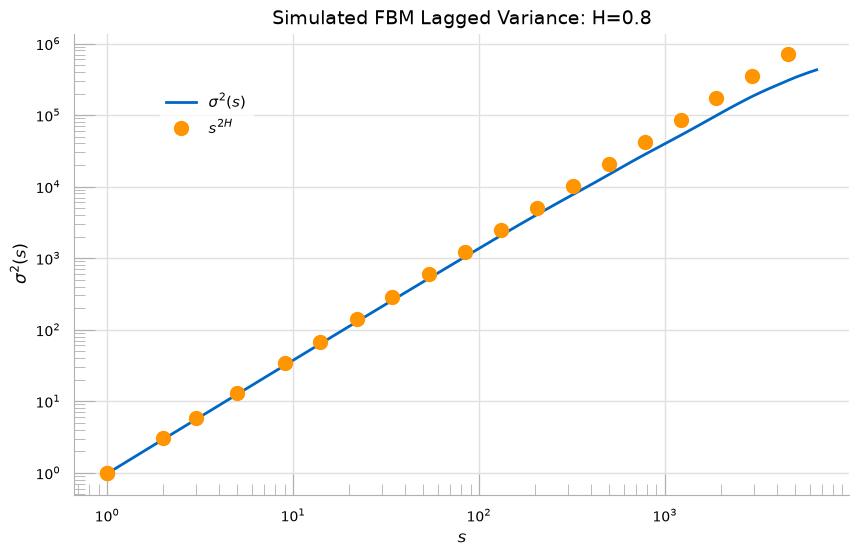

In [136]:
lag_var_plot(samples[2], H_vals[2], npts)

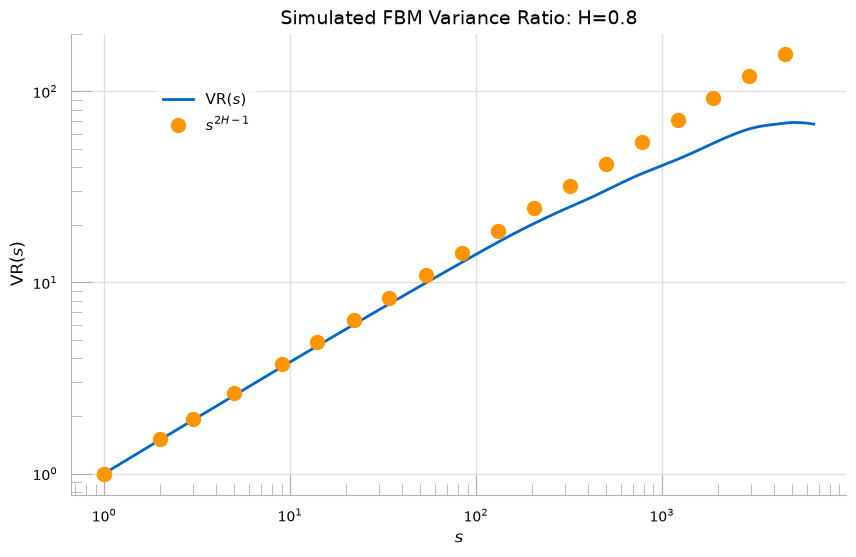

In [137]:
vr_plot(samples[2], H_vals[2], npts)

## Small Sample Size

In the previous verification section a rather large sample size was used to provide enough data to compute accurate averages. In general</br>
this is not practical. here more realistic sample sizes are used to see the impact on the analysis. 

In [138]:
npts = 2**9
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

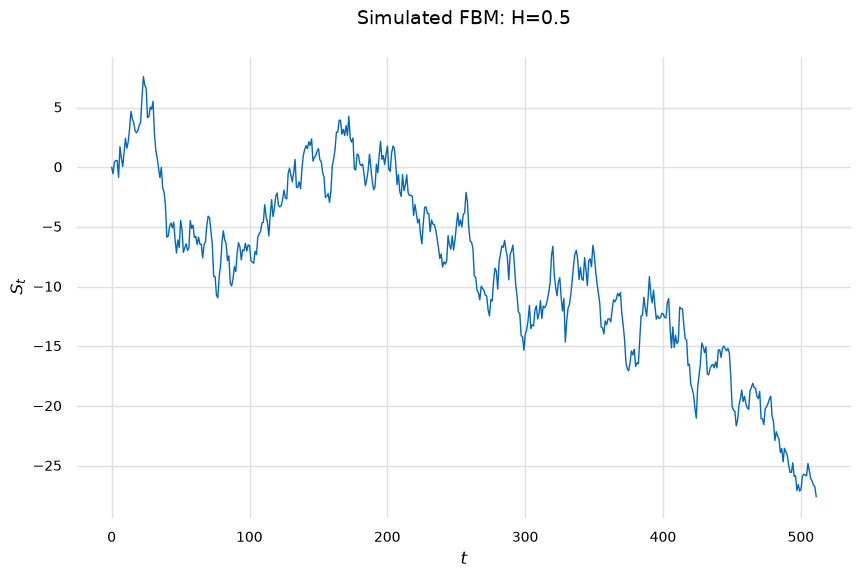

In [139]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

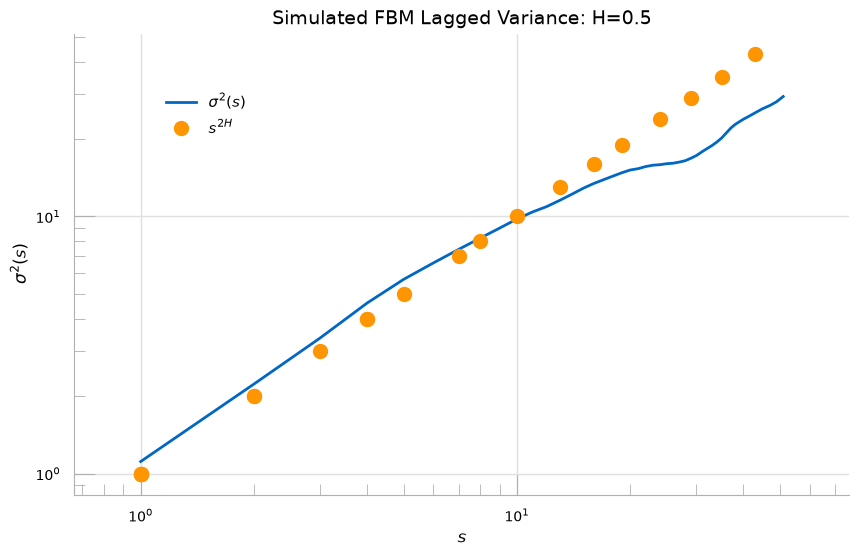

In [140]:
lag_var_plot(samples[0], H_vals[0], npts)

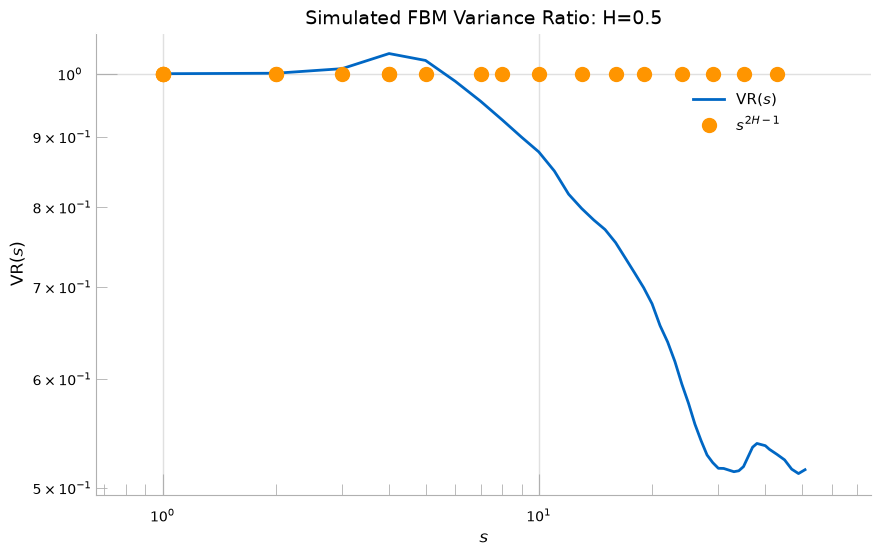

In [141]:
vr_plot(samples[0], H_vals[0], npts)

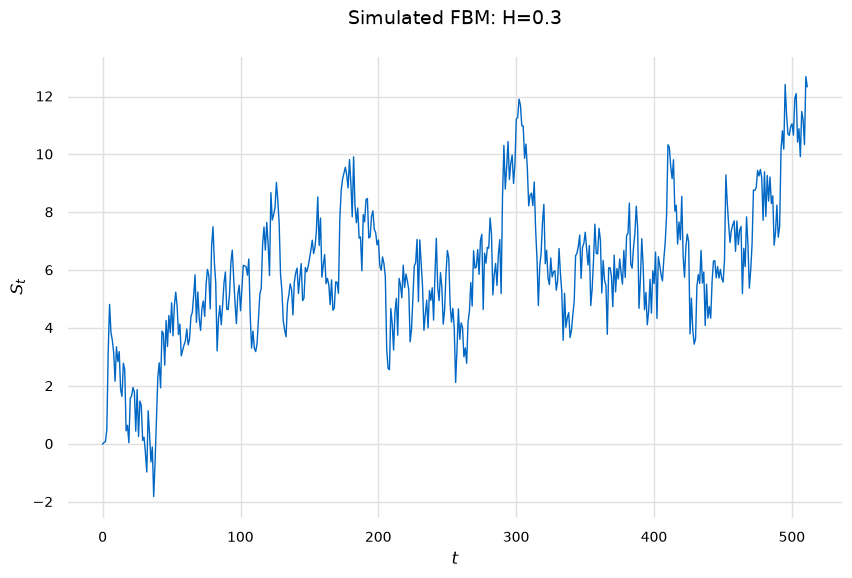

In [142]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

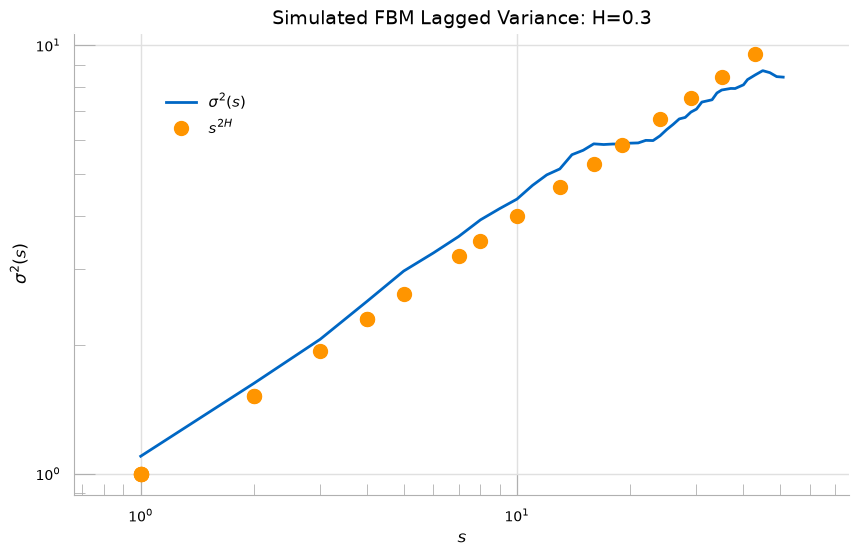

In [143]:
lag_var_plot(samples[1], H_vals[1], npts)

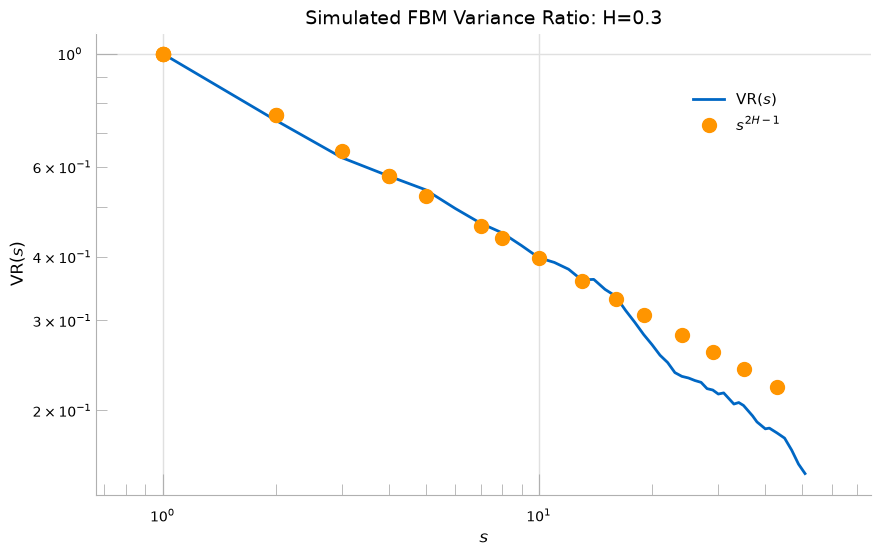

In [144]:
vr_plot(samples[1], H_vals[1], npts)

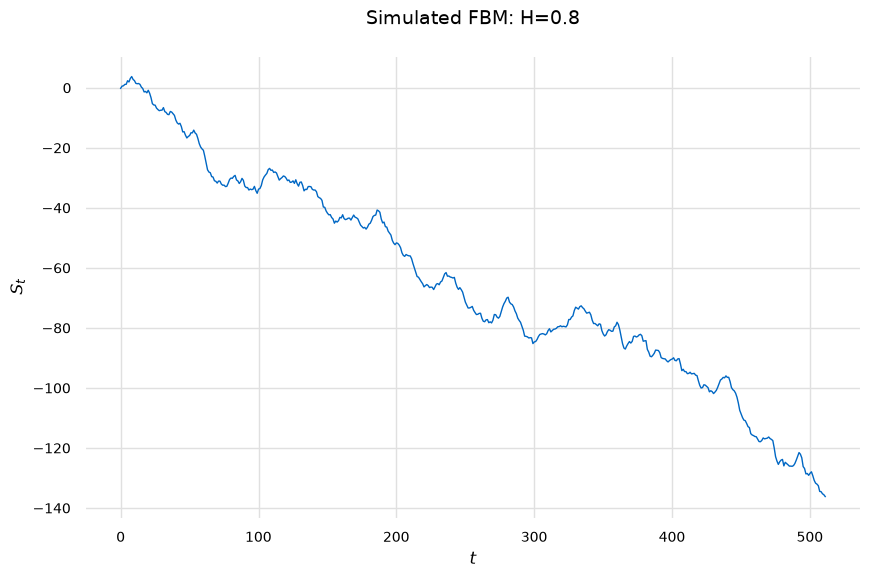

In [145]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

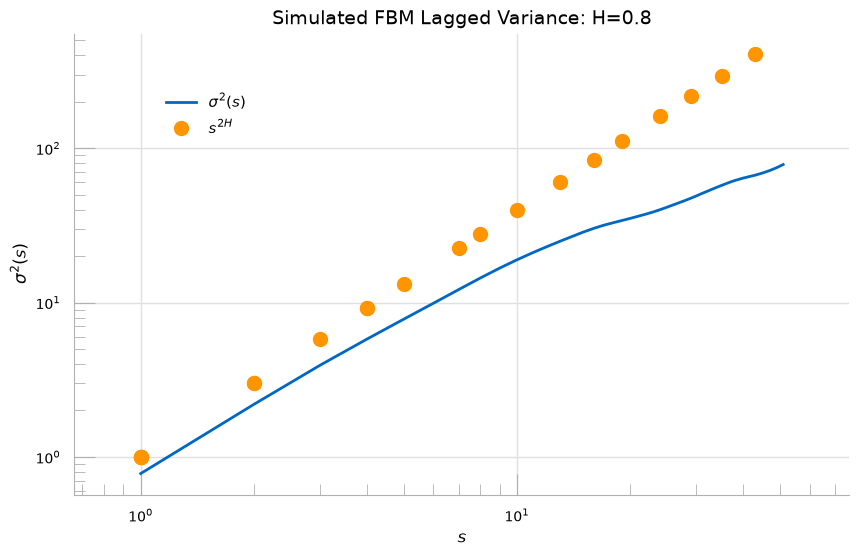

In [146]:
lag_var_plot(samples[2], H_vals[2], npts)

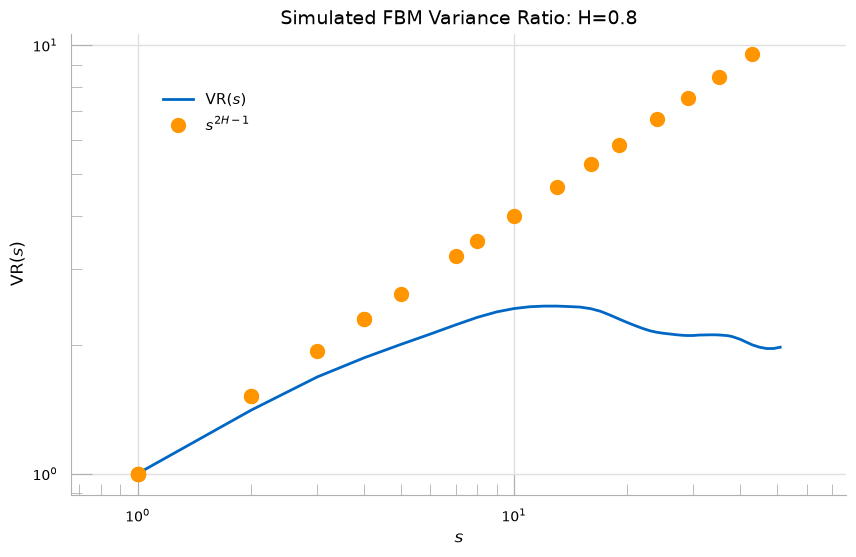

In [147]:
vr_plot(samples[2], H_vals[2], npts)

## Variance Ratio Test Comparison

In this section simulations that test the homoscedastic and heteroscedastic variance ratio test statistic are presented. It is seen that the results are not</br>
significantly different despite the greater cost of the heteroscedastic calculation. First large time series are</br>
analyzed followed by more realistic series lengths. A range of $H$ values is used.

In [148]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.5, 0.3, 0.7]
t, samples = create(H_vals, npts)

### H = 0.5 

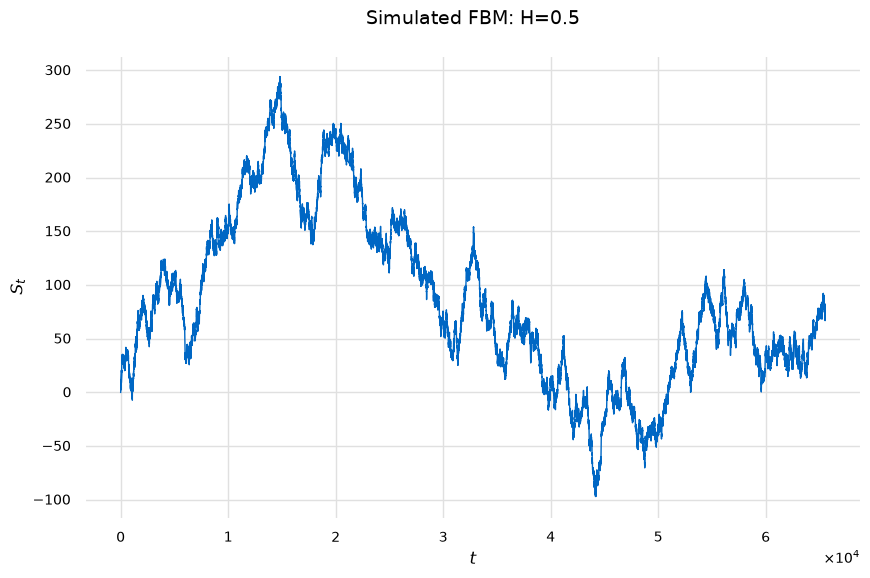

In [149]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [150]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.674 │    0.5   │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.311 │    0.756 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.408 │    0.684 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.616 │    0.538 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [151]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "6fa40875-587c-4a53-9ceb-17cc2215b679",
                "label": "$Z(s)$",
                "value": -0.674109832716306
            },
            "pval": {
                "test_id": "6fa40875-587c-4a53-9ceb-17cc2215b679",
                "label": "$p-value$",
                "value": 0.5002414886829127
            },
            "params": [
                {
                    "test_id": "6fa40875-587c-4a53-9ceb-17cc2215b679",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "6fa40875-587c-4a53-9ceb-17cc2215b679",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "6fa40875-587c-4a53-9ceb-17cc2215b679",
                "label

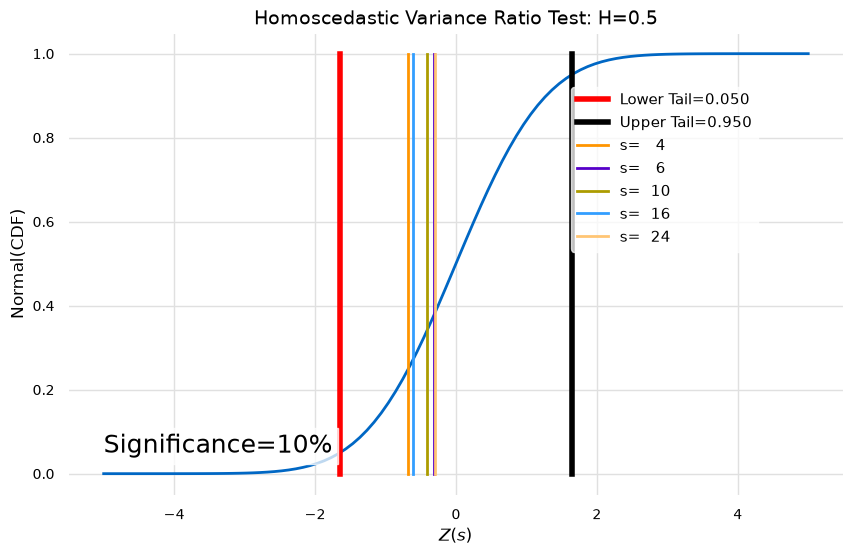

In [152]:
homo_test_stat_plot(result, H_vals[0])

In [153]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.675 │    0.5   │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.311 │    0.756 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.408 │    0.683 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.616 │    0.538 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [154]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "30c5e44a-670b-468a-afa6-ad234dcfeded",
                "label": "$Z(s)$",
                "value": -0.6752462684088688
            },
            "pval": {
                "test_id": "30c5e44a-670b-468a-afa6-ad234dcfeded",
                "label": "$p-value$",
                "value": 0.499519315164652
            },
            "params": [
                {
                    "test_id": "30c5e44a-670b-468a-afa6-ad234dcfeded",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "30c5e44a-670b-468a-afa6-ad234dcfeded",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "30c5e44a-670b-468a-afa6-ad234dcfeded",
                "label

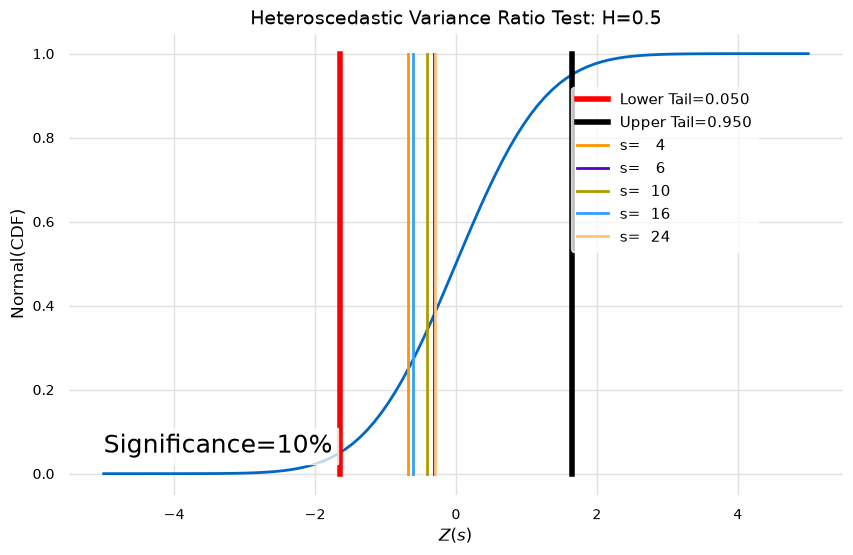

In [155]:
hetero_test_stat_plot(result, H_vals[0])

### H = 0.3

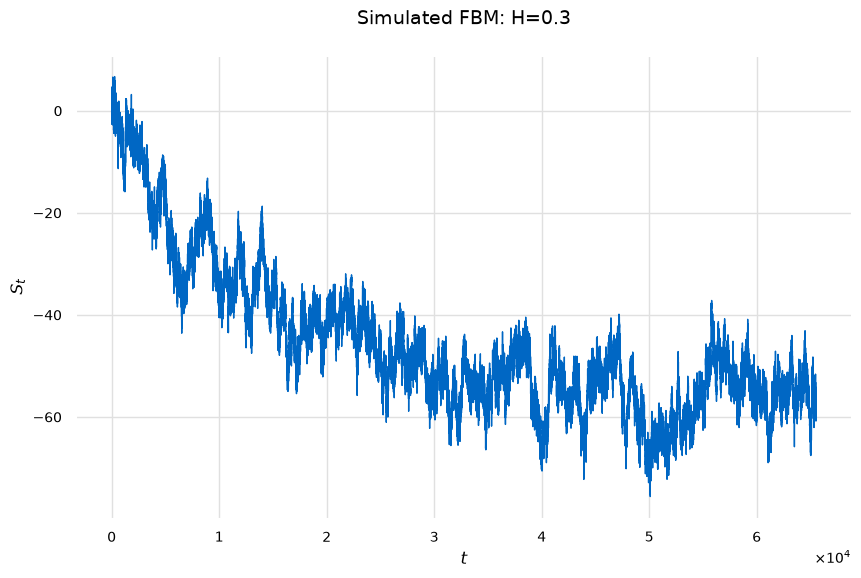

In [156]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [157]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -57.972 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -53.004 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -45.86  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -39.212 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

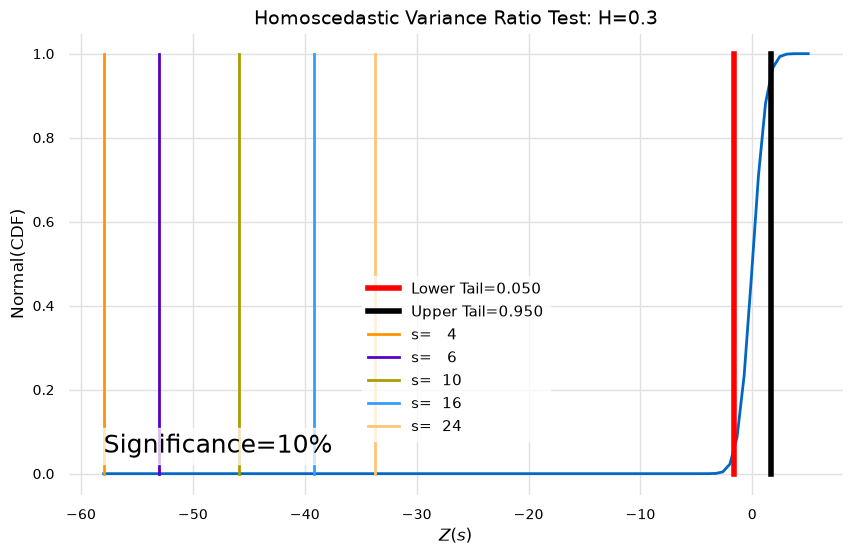

In [158]:
homo_test_stat_plot(result, H_vals[1])

In [159]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -55.658 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -51.487 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -45.03  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.746 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

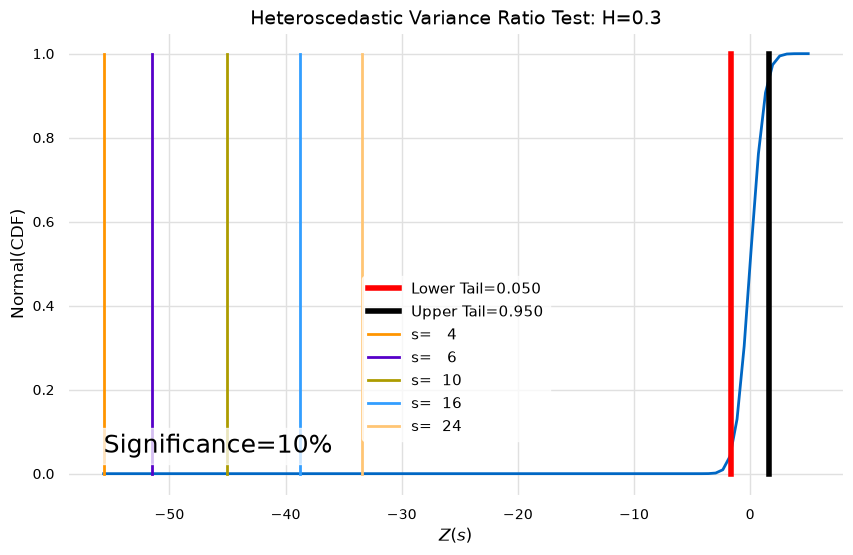

In [160]:
hetero_test_stat_plot(result, H_vals[1])

### H=0.7

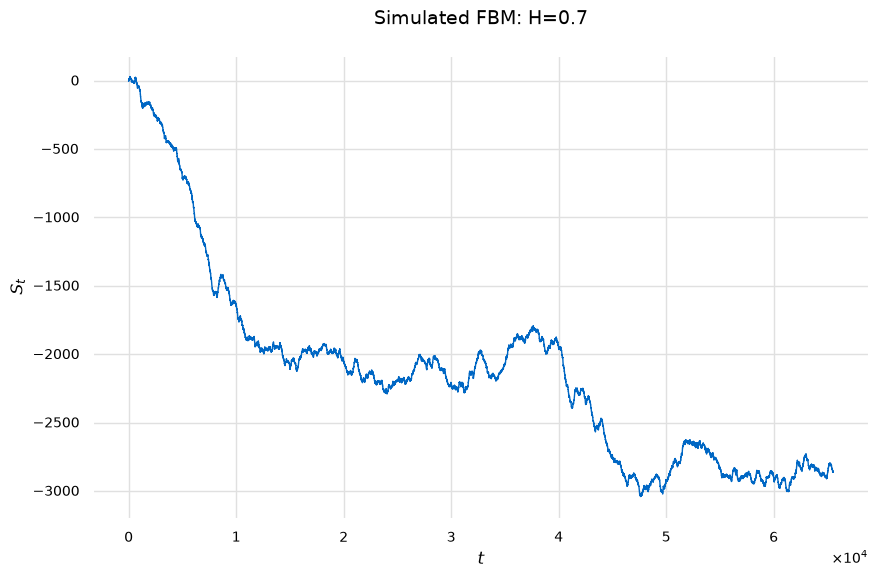

In [161]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [162]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ 103.338 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 110.633 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 117.391 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 120.794 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

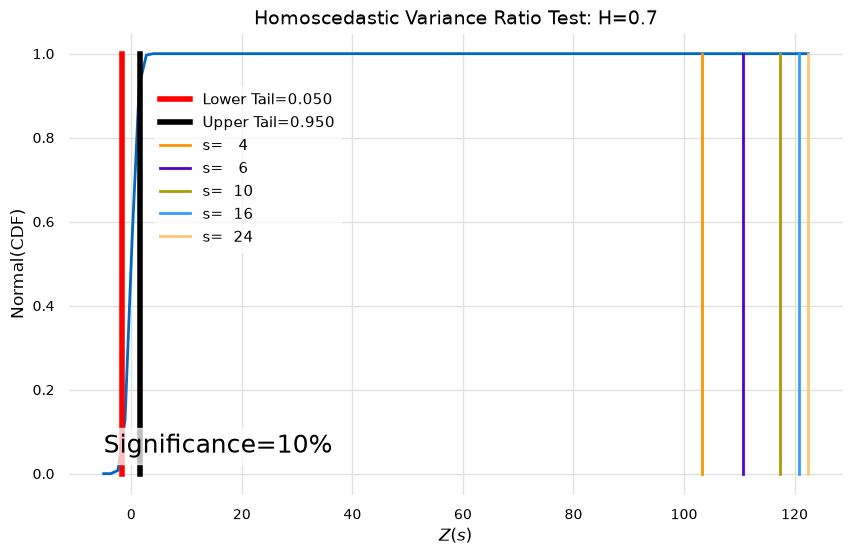

In [163]:
homo_test_stat_plot(result, H_vals[2])

In [164]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │  95.65  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 103.906 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 112.125 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 116.87  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

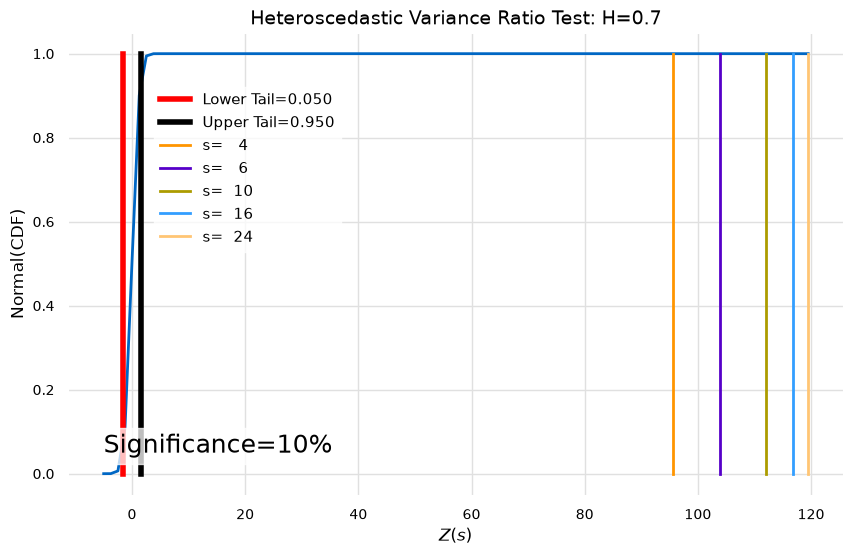

In [165]:
hetero_test_stat_plot(result, H_vals[2])

### Values Near H=0.5

The performance of the homoscedastic and heteroscedastic for values near $H=0.5$ is evaluated.

In [166]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.475, 0.49, 0.51, 0.525]
t, samples = create(H_vals, npts)

#### H=0.51

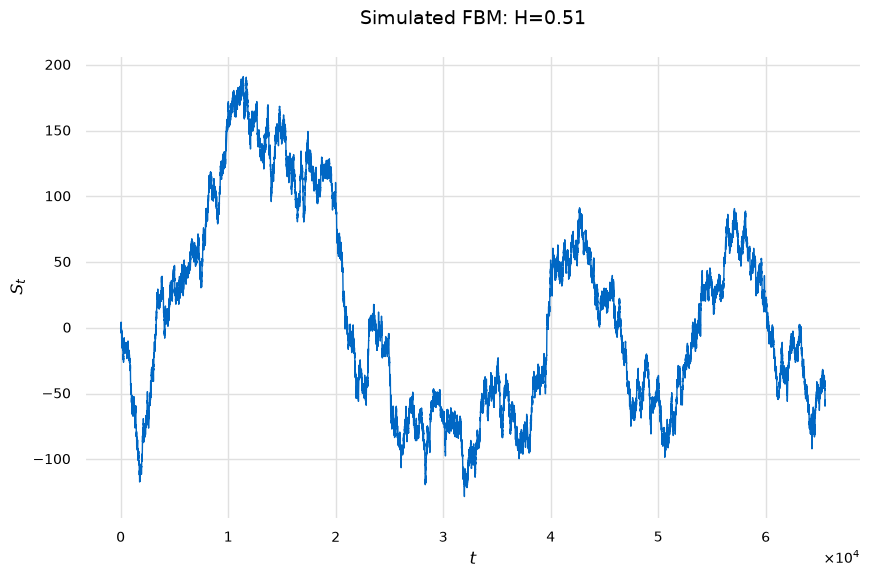

In [167]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [168]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  5.606 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  5.539 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  2.102 │    0.036 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │  1.414 │    0.157 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

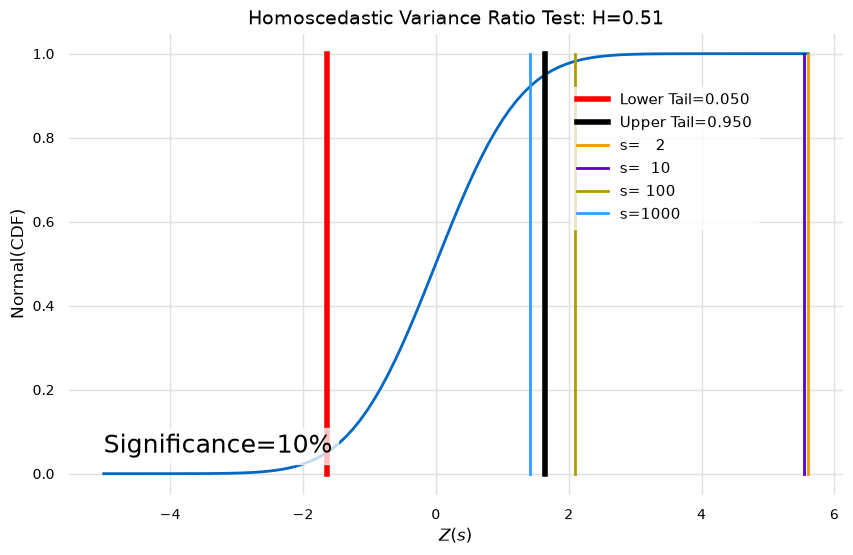

In [169]:
homo_test_stat_plot(result, H_vals[2])

In [170]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  5.599 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  5.532 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  2.102 │    0.036 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │  1.417 │    0.157 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

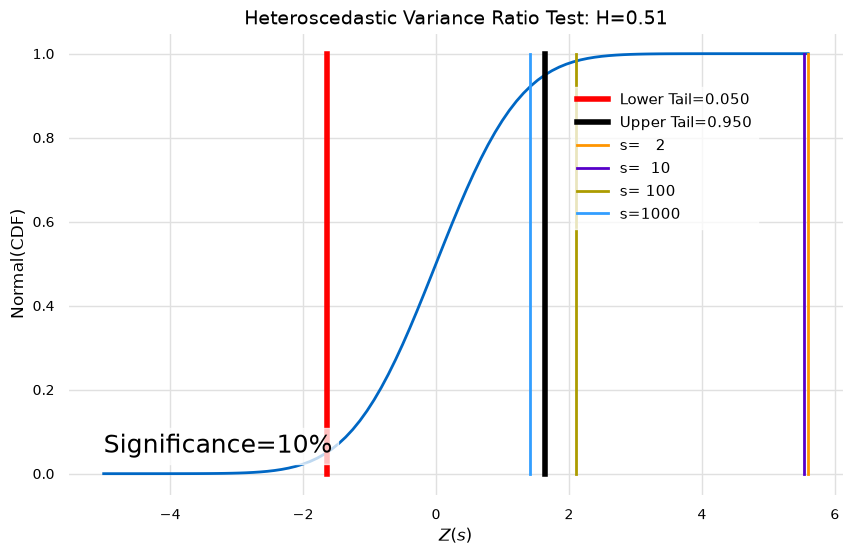

In [171]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.49

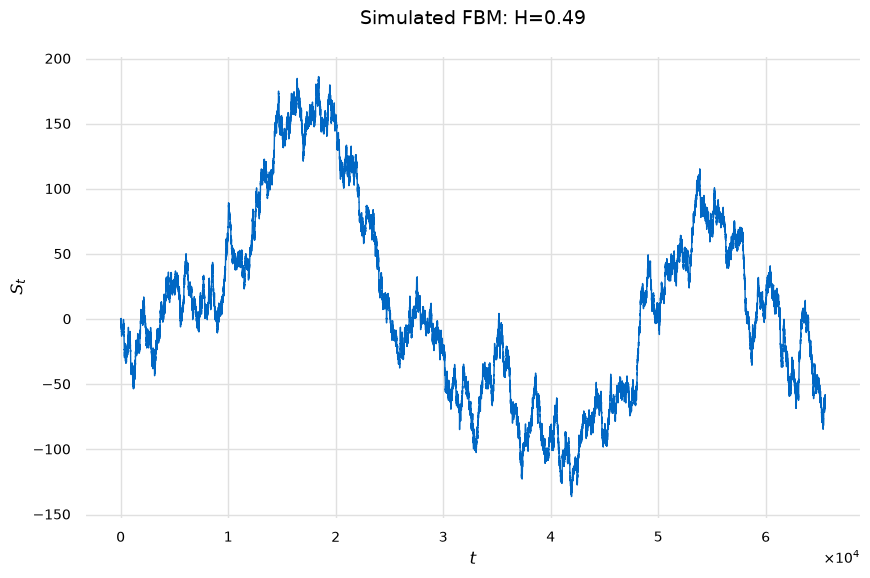

In [172]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [173]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -3.506 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -4.648 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -0.625 │    0.532 │ Passed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.103 │    0.918 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

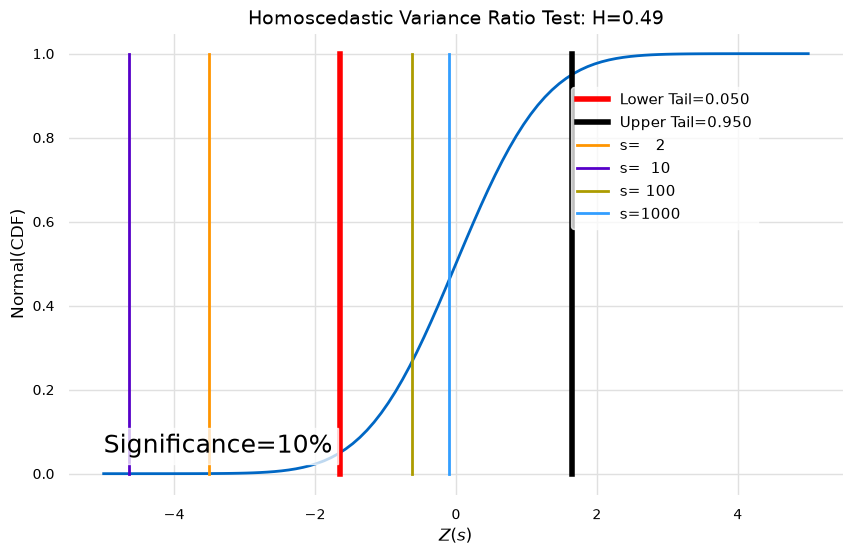

In [174]:
homo_test_stat_plot(result, H_vals[1])

In [175]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -3.51  │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -4.654 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -0.625 │    0.532 │ Passed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.103 │    0.918 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

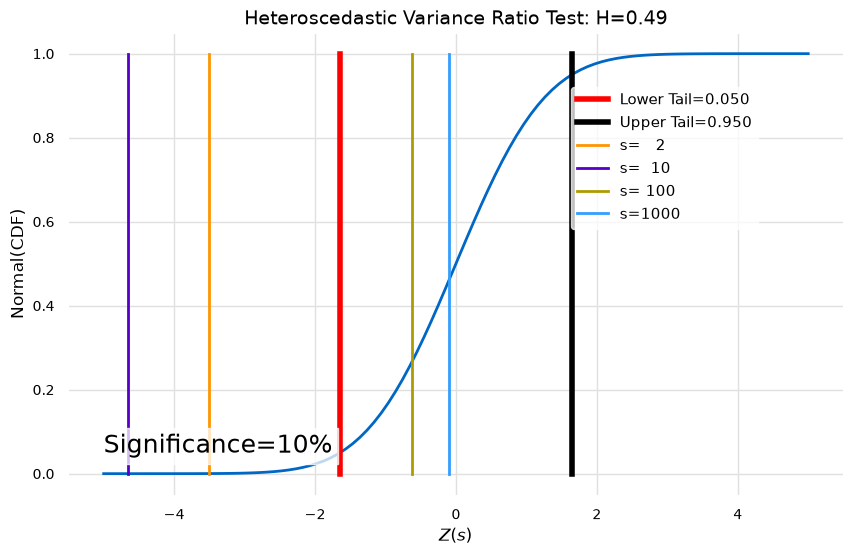

In [176]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.475

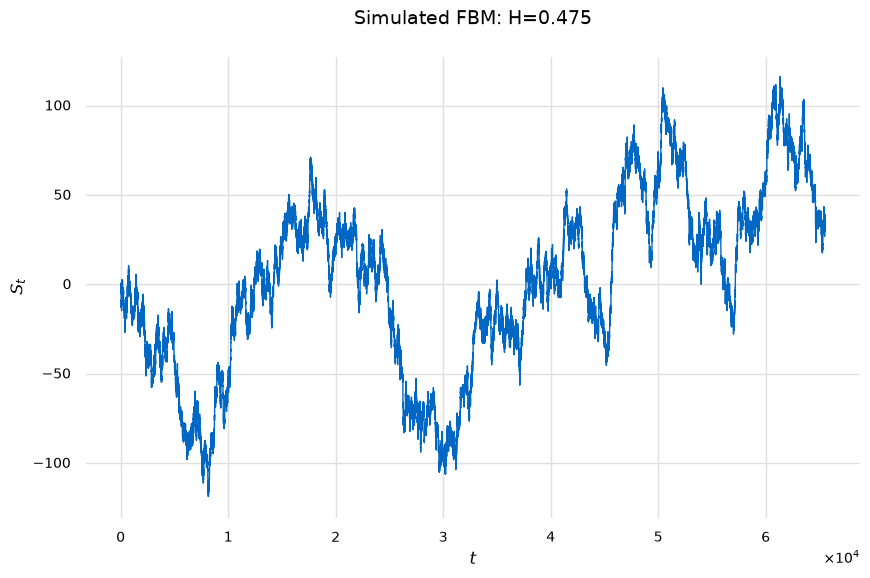

In [177]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [178]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -8.929 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -9.012 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -4.004 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.926 │    0.054 │ Failed   │
╘══════╧════════╧══════════╧══════════╛

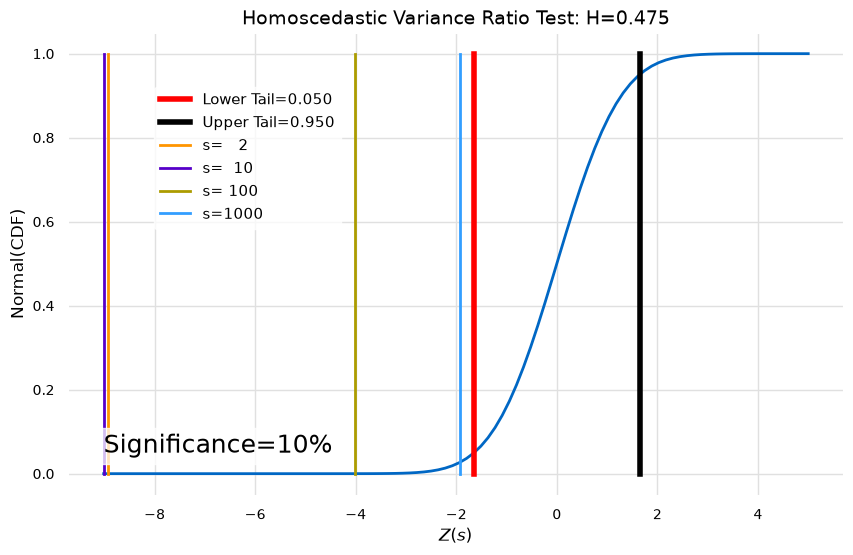

In [179]:
homo_test_stat_plot(result, H_vals[0])

In [180]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -8.944 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -9.022 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -4.001 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.929 │    0.054 │ Failed   │
╘══════╧════════╧══════════╧══════════╛

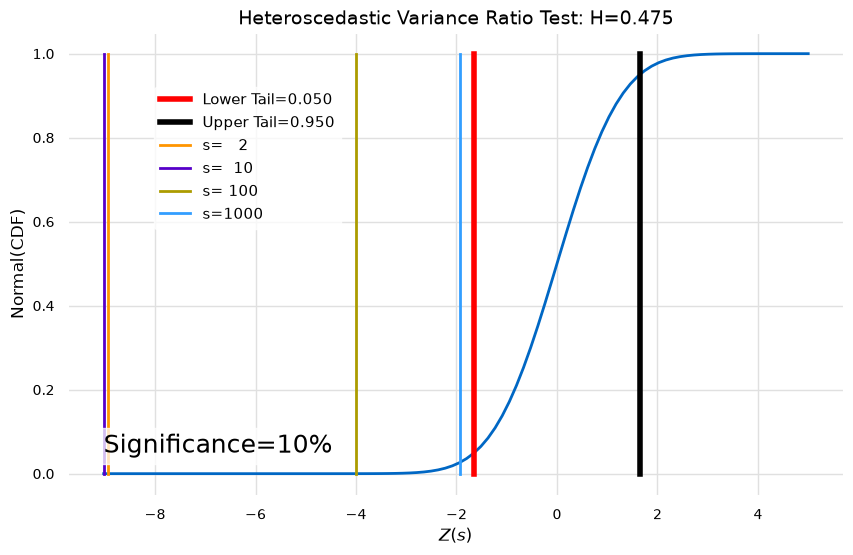

In [181]:
hetero_test_stat_plot(result, H_vals[0])

### Small Sample Size

In [182]:
npts = 2**9
s_vals = [4, 10, 25, 50, 100]
H_vals = [0.5, 0.7, 0.3]
t, samples = create(H_vals, npts)

#### H=0.5

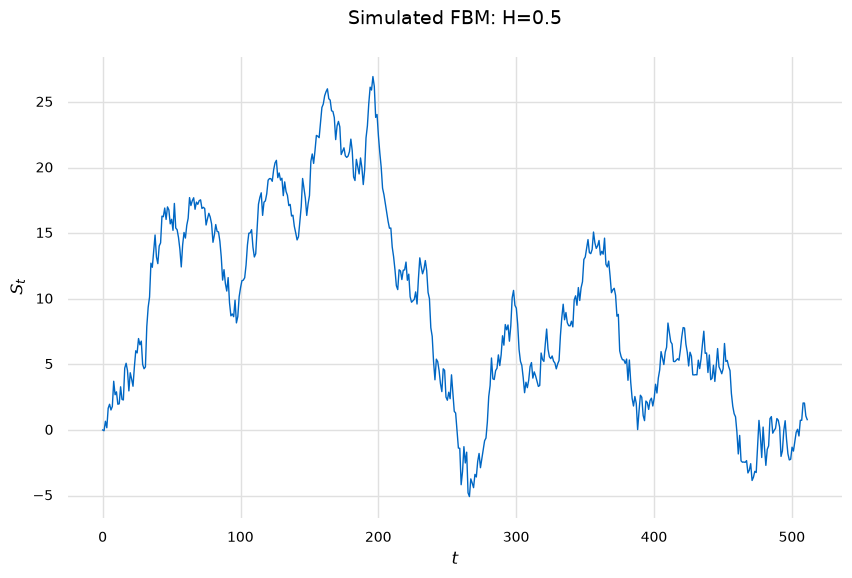

In [183]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [184]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  1.031 │    0.303 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.242 │    0.025 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.423 │    0.015 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1.274 │    0.203 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  0

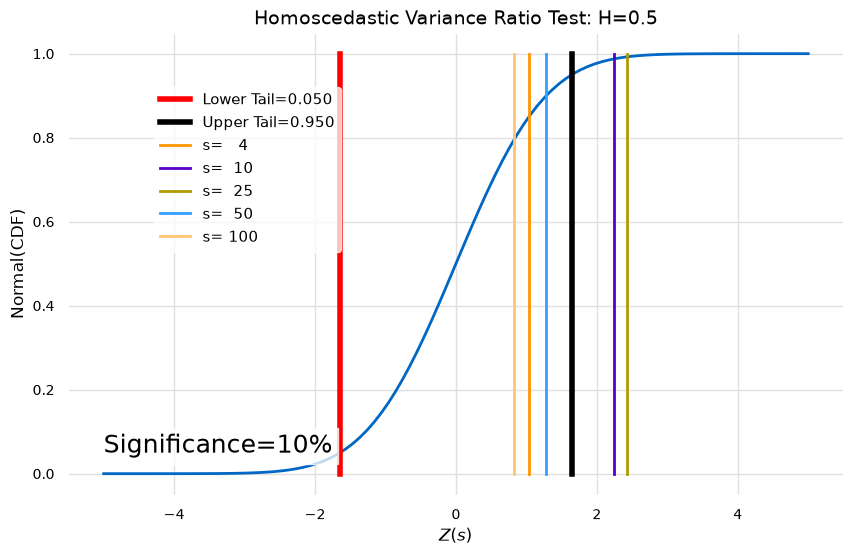

In [185]:
homo_test_stat_plot(result, H_vals[0])

In [186]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  1.045 │    0.296 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.219 │    0.027 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.404 │    0.016 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1.278 │    0.201 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  0

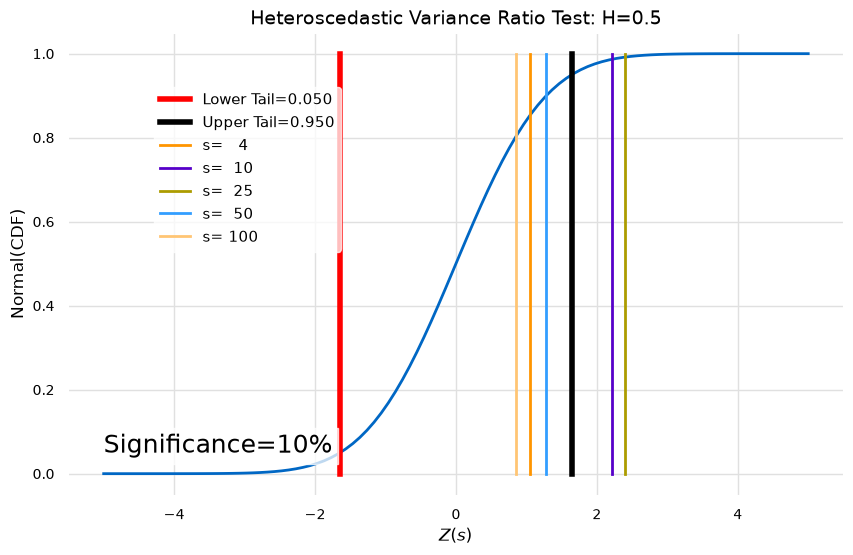

In [187]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.7

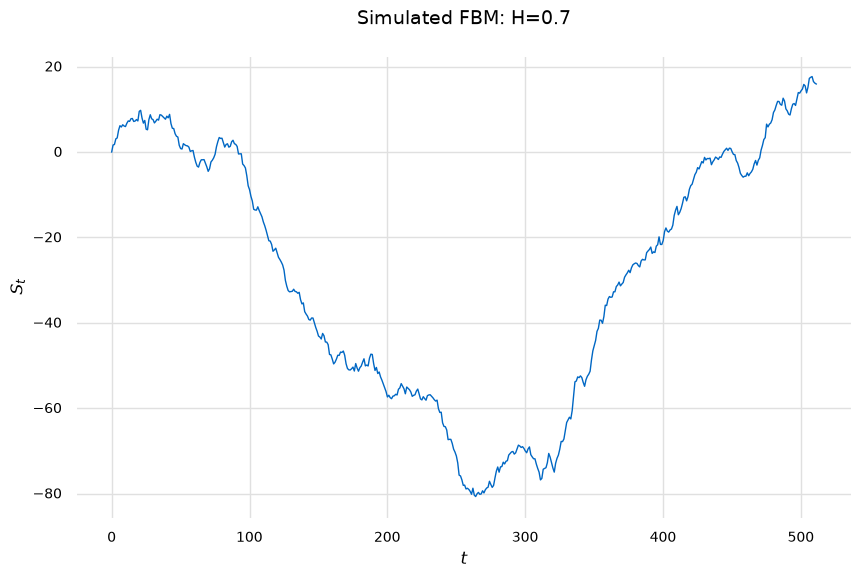

In [188]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [189]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  9.486 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ 13.793 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ 19.432 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ 23.353 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ 34

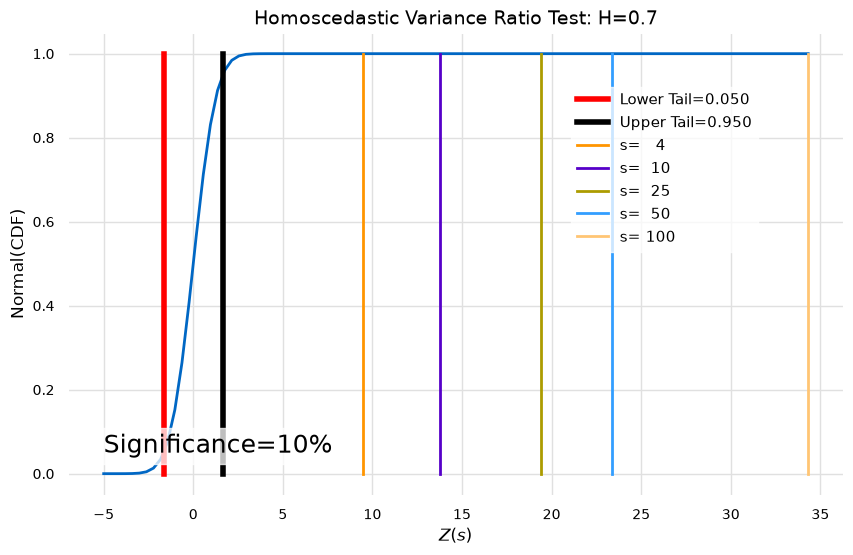

In [190]:
homo_test_stat_plot(result, H_vals[1])

In [191]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  8.849 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ 13.097 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ 18.78  │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ 23.008 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ 34

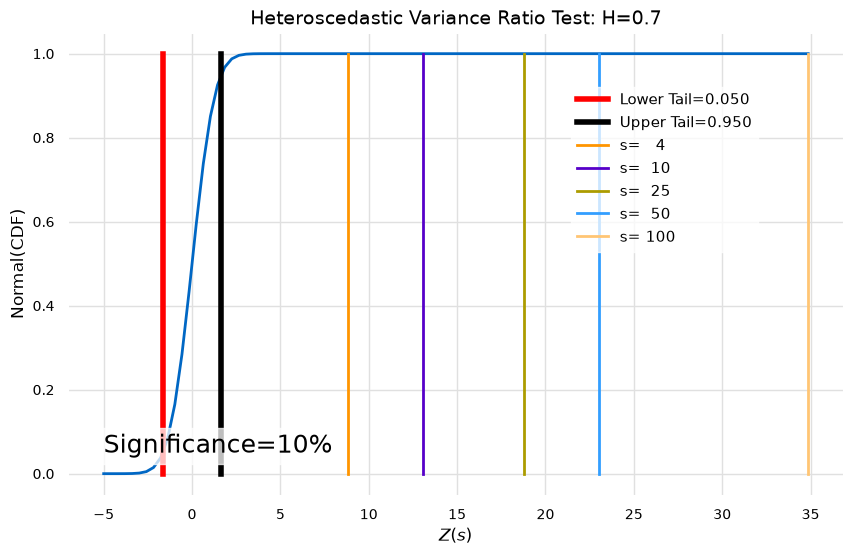

In [192]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.3

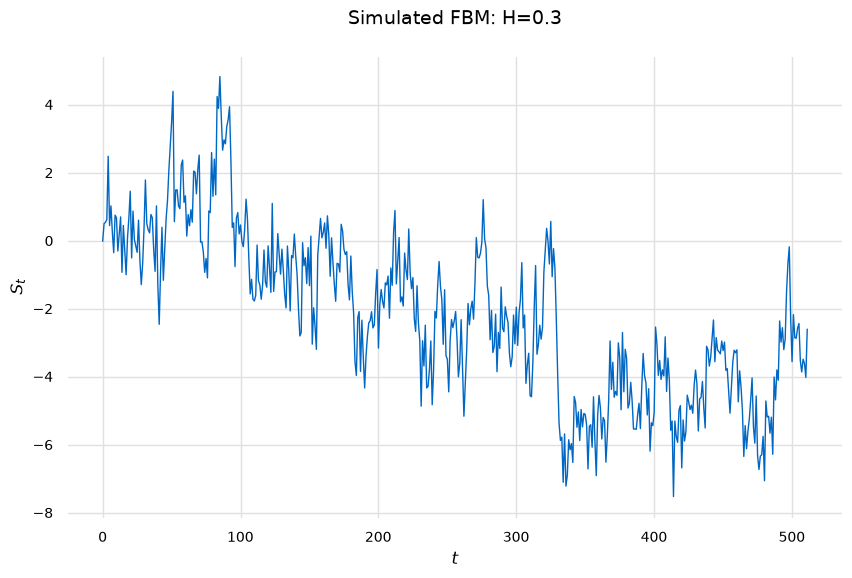

In [193]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [194]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -6.08  │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -4.354 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -3.285 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.577 │    0.01  │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

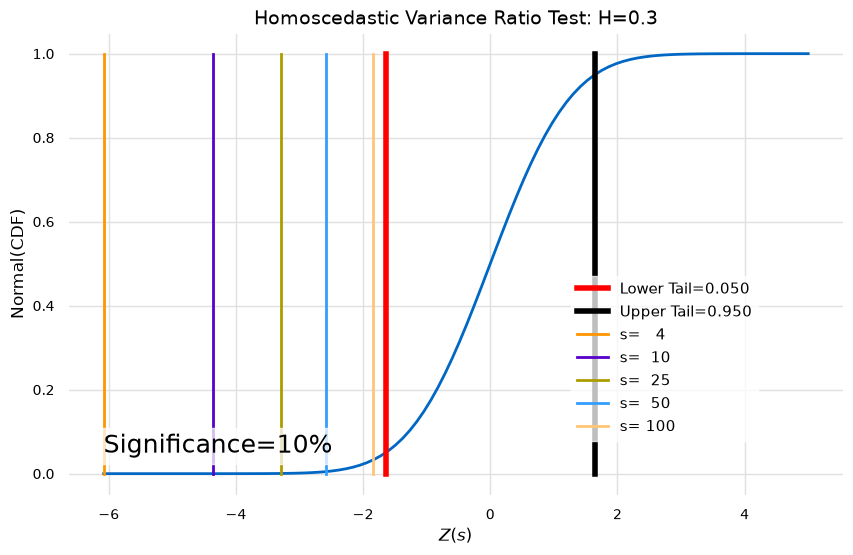

In [195]:
homo_test_stat_plot(result, H_vals[2])

In [196]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -6.039 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -4.422 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -3.343 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.634 │    0.008 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

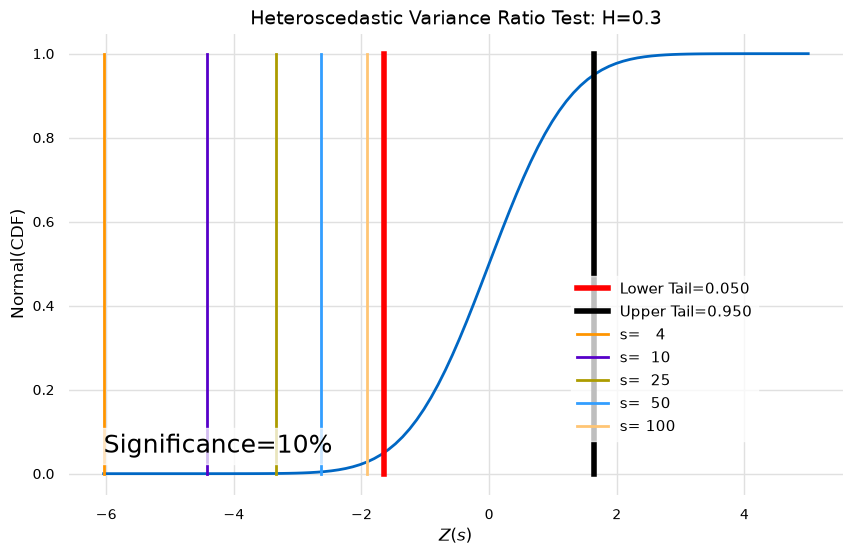

In [197]:
hetero_test_stat_plot(result, H_vals[2])

### Values Near H=0.5

In [198]:
npts = 2**9
s_vals = [2, 4, 10, 25, 50]
H_vals = [0.49, 0.45, 0.4, 0.51, 0.55]
t, samples = create(H_vals, npts)

#### H=0.49

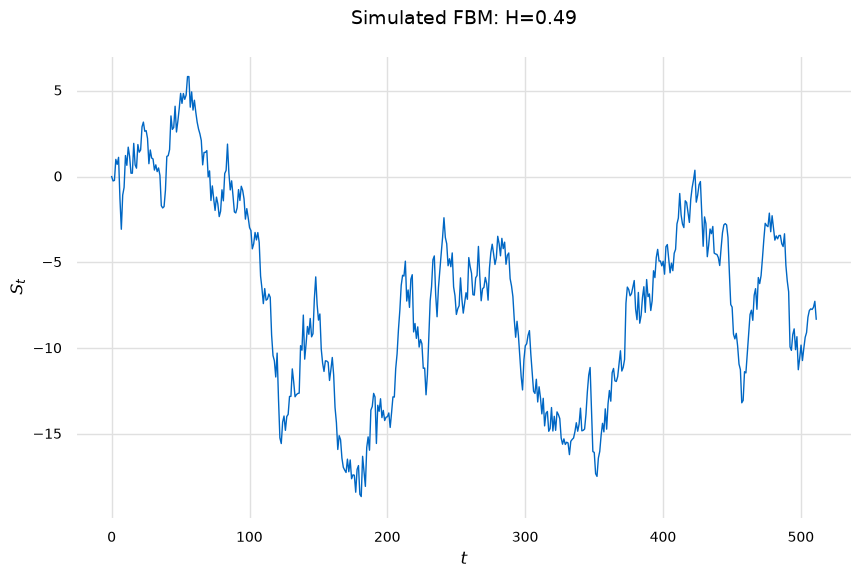

In [199]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [200]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.021 │    0.307 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -0.466 │    0.641 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.121 │    0.904 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.069 │    0.945 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

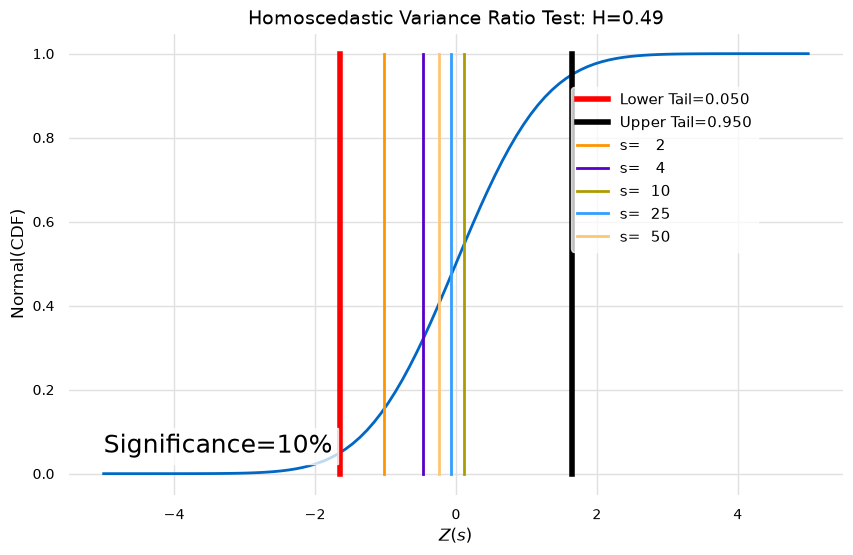

In [201]:
homo_test_stat_plot(result, H_vals[0])

In [202]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.02  │    0.308 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -0.461 │    0.645 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.119 │    0.905 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.069 │    0.945 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

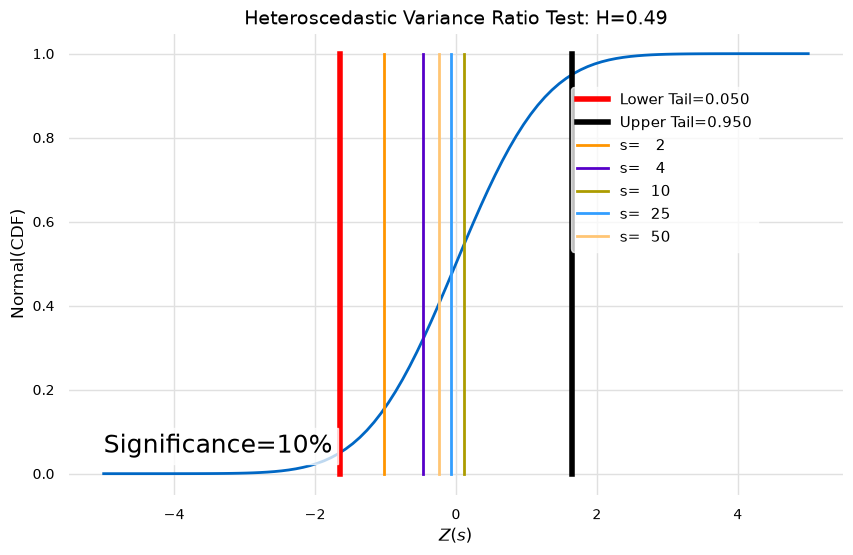

In [203]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.45

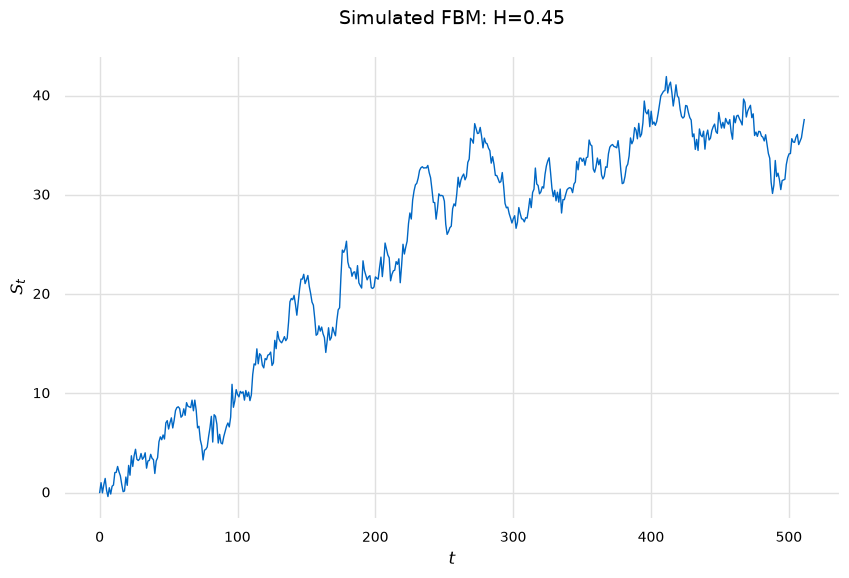

In [204]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [205]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.76  │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.477 │    0.14  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.768 │    0.442 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.106 │    0.269 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

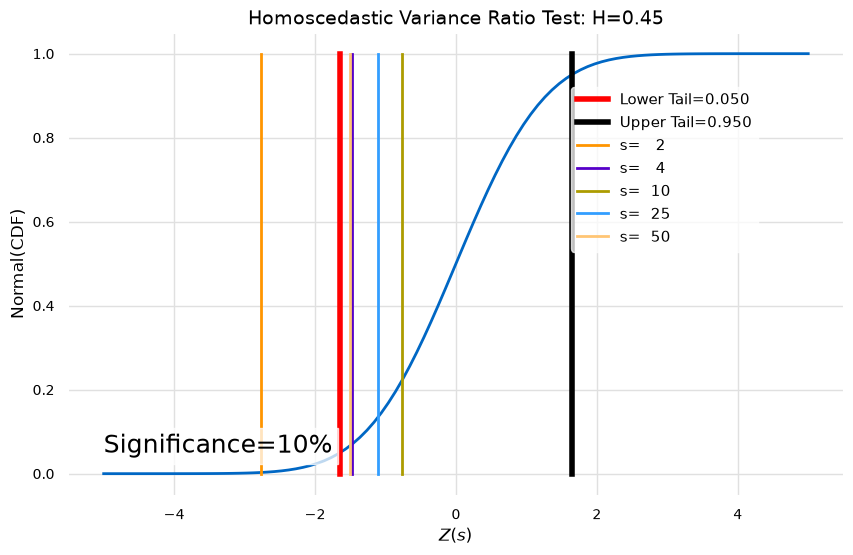

In [206]:
homo_test_stat_plot(result, H_vals[1])

In [207]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.459 │    0.014 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.382 │    0.167 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.762 │    0.446 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.118 │    0.264 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

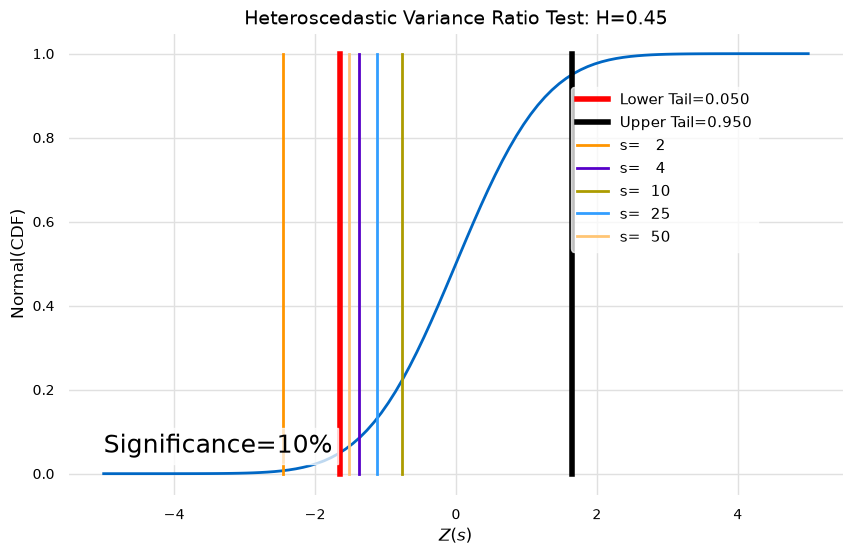

In [208]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.4

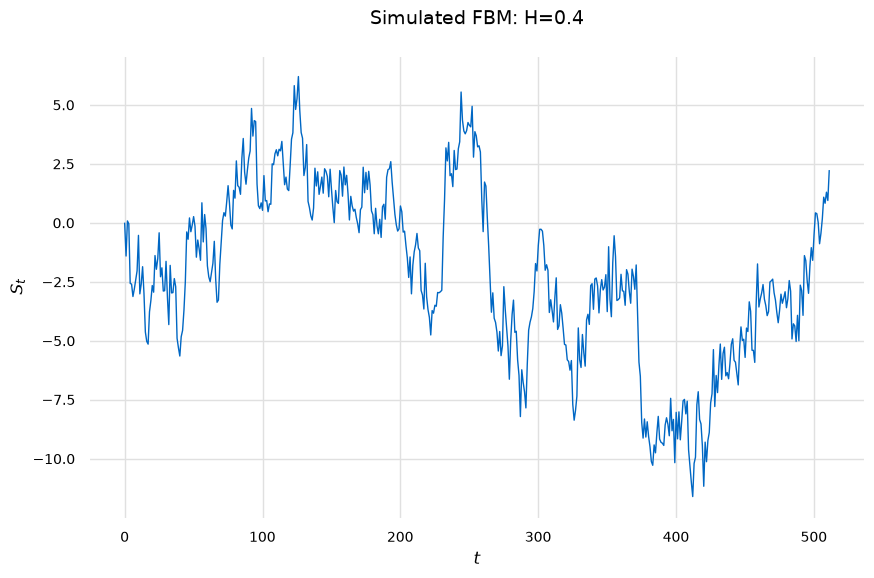

In [209]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [210]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -3.734 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.835 │    0.005 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.464 │    0.014 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.814 │    0.07  │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

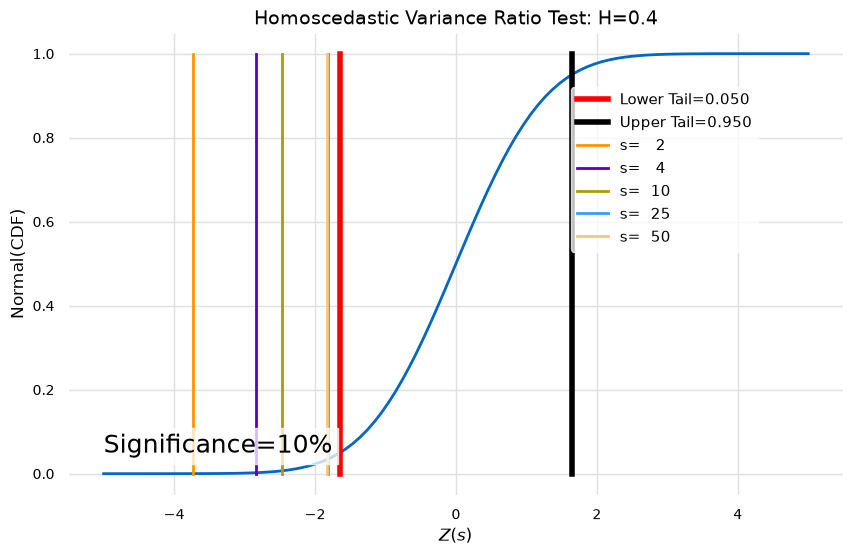

In [211]:
homo_test_stat_plot(result, H_vals[2])

In [212]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -3.548 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.757 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.432 │    0.015 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.828 │    0.068 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

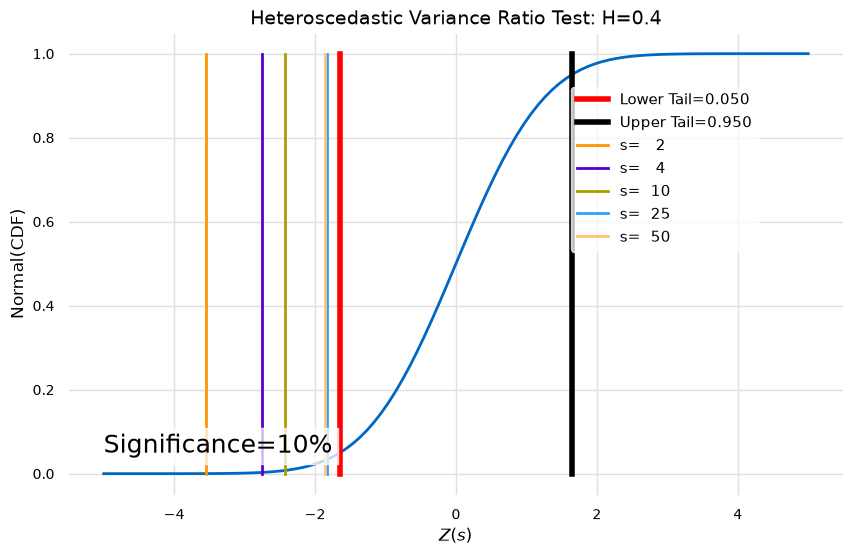

In [213]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.51

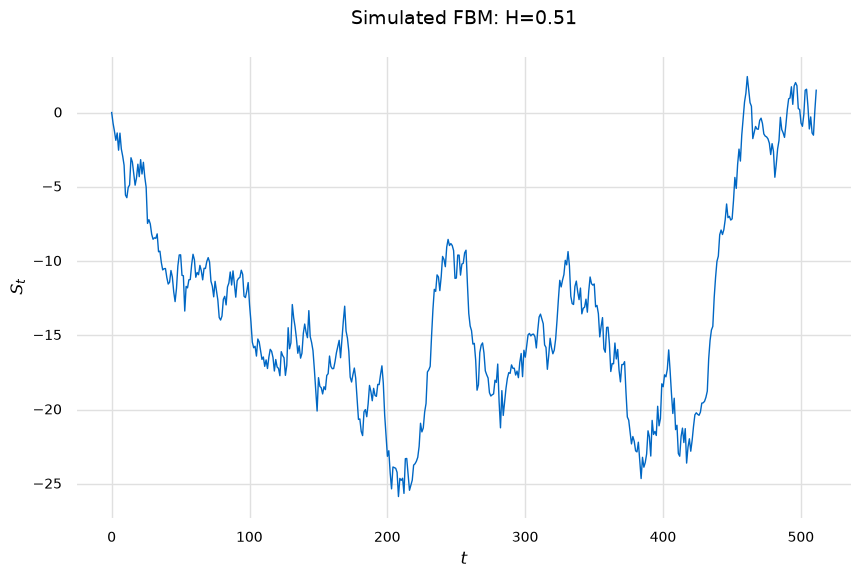

In [214]:
title = f"Simulated FBM: H={H_vals[3]}"
curve(samples[3], t[3], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [215]:
result, result_model = fbm.compute_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  0.598 │    0.55  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  0.611 │    0.541 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.844 │    0.065 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.453 │    0.014 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1

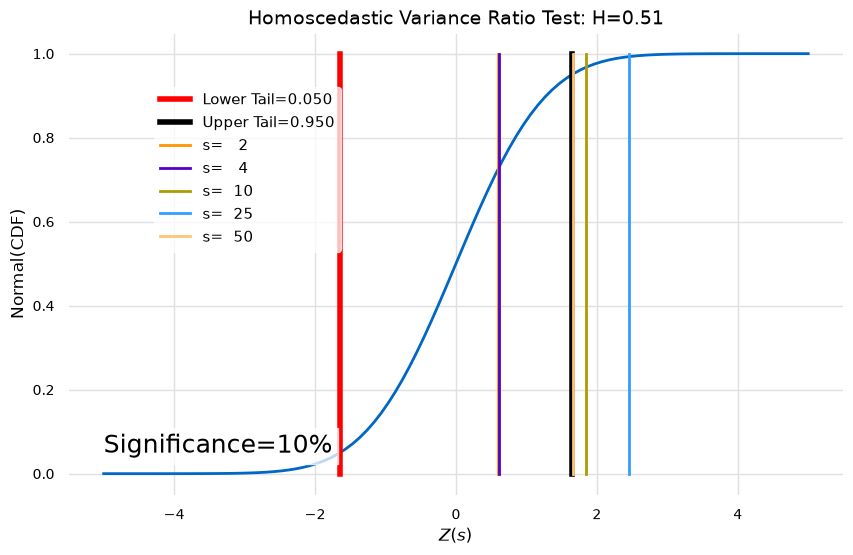

In [216]:
homo_test_stat_plot(result, H_vals[3])

In [217]:
result, result_model = fbm.compute_hetero_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  0.577 │    0.564 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  0.592 │    0.554 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.807 │    0.071 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.469 │    0.014 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1

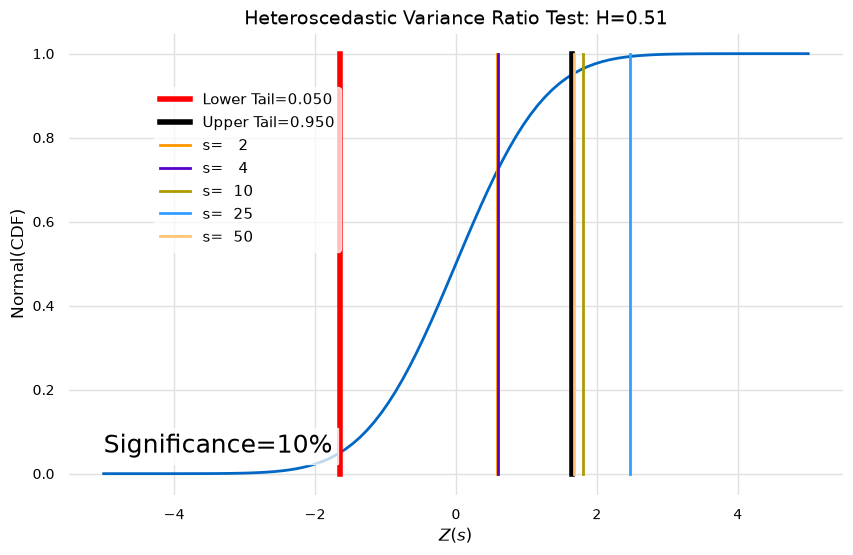

In [218]:
hetero_test_stat_plot(result, H_vals[3])

#### H=0.55

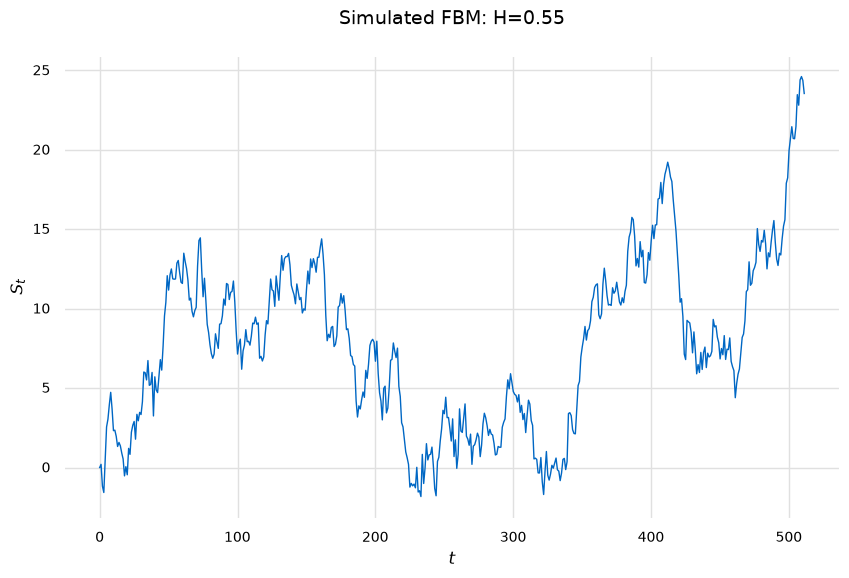

In [219]:
title = f"Simulated FBM: H={H_vals[4]}"
curve(samples[4], t[4], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [220]:
result, result_model = fbm.compute_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.162 │    0.871 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  1.086 │    0.277 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.913 │    0.361 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.014 │    0.989 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

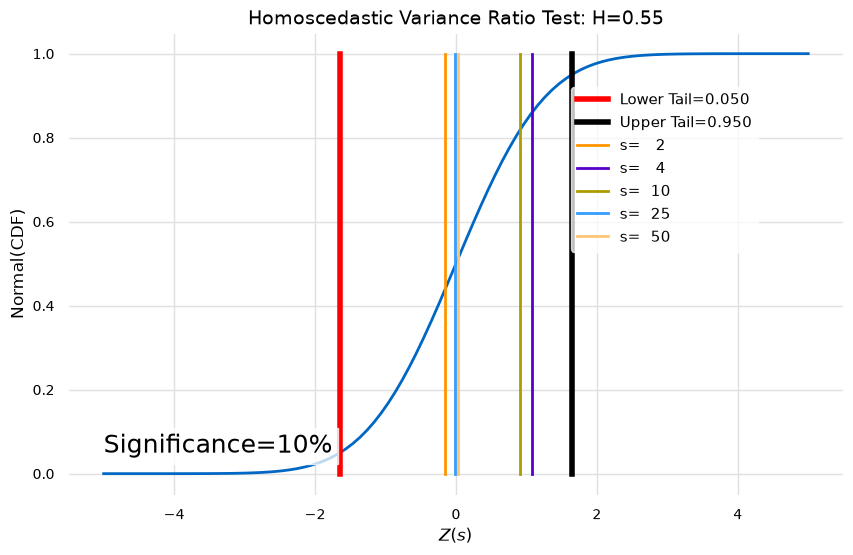

In [221]:
homo_test_stat_plot(result, H_vals[4])

In [222]:
result, result_model = fbm.compute_hetero_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.16  │    0.873 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  1.084 │    0.278 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.91  │    0.363 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.015 │    0.988 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

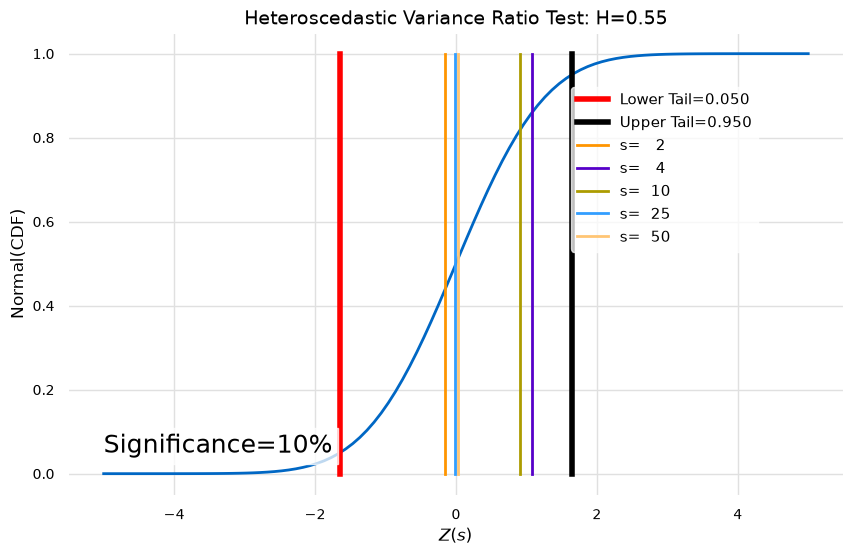

In [223]:
hetero_test_stat_plot(result, H_vals[4])

## Variance Ratio Test

Here the performance of the variance ratio test is evaluated. In the previous analysis the performance of the homoscedastic test was not significantly different</br>
than the heteroscedastic test. Since the homoscedastic test is much faster it is used. The values of the variance ratio test statistic for $0 < H < \frac{1}{2}$, $H=\frac{1}{2}$</br>
and $\frac{1}{2} < H < 1$ respectively satisfy $Z(s) < 0$, $Z(s) = 0$ and $Z(s) > 0$. This follows from the variance ratio, $\text{VR}(s)$ satisfying $0 < \text{VR}(s) < 1$, $\text{VR}(s)=1$ and $\text{VR}(s) > 1$</br>
in that same regions. Plots of $Z(s)$ for these regions are shown below. It is seen for $0 < H < \frac{1}{2}$ that $Z(s)$ is an increasing function of $s$ and for $\frac{1}{2} < H < 1$</br>
$Z(s)$ has a more complex behavior but is increasing for smaller values of $s$. It follows that eventually for some value of $s$ the test will likely fail. This makes interpreting the tests</br> 
results somewhat difficult. In the previous analysis where $\text{VR}(s)$ was compared to $\sigma s^{2H-1}$ it was seen that for a series with $2^9$ points the the two values agreed well for</br>
up to $s=2^8$. This motivates evaluating $Z(s)$ in regions where it is always increasing using a sequence of values of $s$ satisfying $s \le 25$. For this range the agreement between $\text{VR}(s)$</br>
and $\sigma s^{2H-1}$ was best. $Z(s)$ is evaluated for each $s$ and the result is pass if at least one test passes and failed otherwise.

### $H \le \frac{1}{2}$

In [224]:
npts = 2**9
s_min=2.0
s_max=npts/2
s_npts=int(s_max - s_min + 1)

In [225]:
H_vals = [0.1, 0.2, 0.3, 0.4, 0.5]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

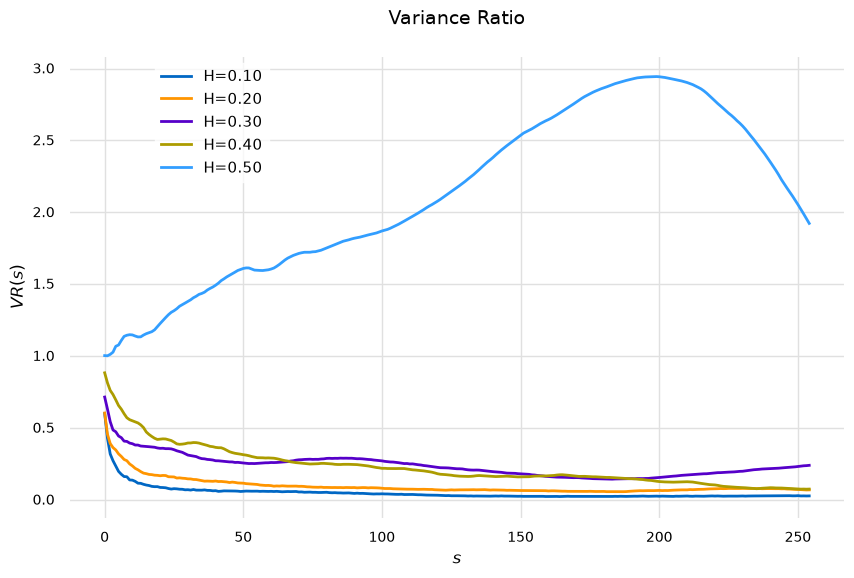

In [226]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H \ge \frac{1}{2}$

In [227]:
H_vals = [0.5, 0.6, 0.7, 0.8, 0.89]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

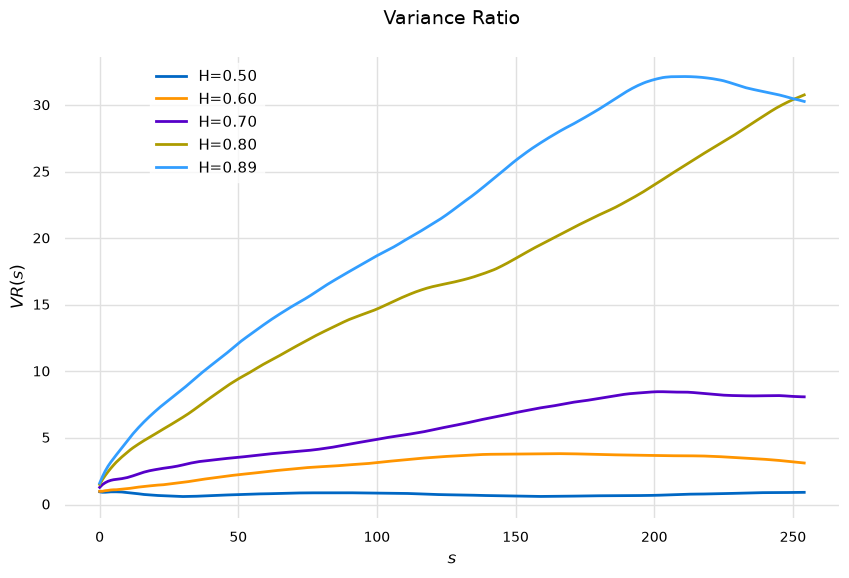

In [228]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H = 0.5$

Here a two tailed test for brownian motion is performed. This test is successful if the result is **PASSED**

In [229]:
H=0.5
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.399 │    0.69  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.474 │    0.636 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.753 │    0.451 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -1.112 │    0.266 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -1

In [230]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "0906bce9-437b-4ae8-acb4-39ce31ee2e83",
                "label": "$Z(s)$",
                "value": -0.39894941090592306
            },
            "pval": {
                "test_id": "0906bce9-437b-4ae8-acb4-39ce31ee2e83",
                "label": "$p-value$",
                "value": 0.6899304804353101
            },
            "params": [
                {
                    "test_id": "0906bce9-437b-4ae8-acb4-39ce31ee2e83",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "0906bce9-437b-4ae8-acb4-39ce31ee2e83",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "0906bce9-437b-4ae8-acb4-39ce31ee2e83",
                "lab

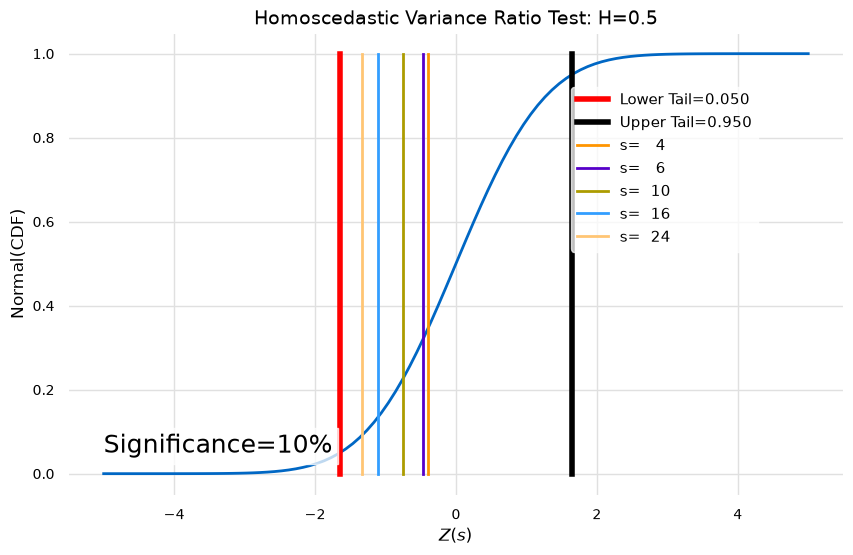

In [231]:
homo_test_stat_plot(result, H)

In [232]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.399 │    0.655 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.474 │    0.682 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.753 │    0.774 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -1.112 │    0.867 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -1.33  │    0.908 │ Pas

In [233]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "be34c59a-bf13-4d05-904e-1c56696e5fc7",
                "label": "$Z(s)$",
                "value": -0.39894941090592306
            },
            "pval": {
                "test_id": "be34c59a-bf13-4d05-904e-1c56696e5fc7",
                "label": "$p-value$",
                "value": 0.6550347597823449
            },
            "params": [
                {
                    "test_id": "be34c59a-bf13-4d05-904e-1c56696e5fc7",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "be34c59a-bf13-4d05-904e-1c56696e5fc7",
                "label": "10%",
                "value": 0.1
            },
            "lower": null,
            "upper": {
                "test_id": "be34c59a-bf13-4d05-904e

In [234]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.399 │    0.345 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.474 │    0.318 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.753 │    0.226 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -1.112 │    0.133 │ Passed   │
├─────┼────────┼──────────┼───────

In [235]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "ccba6d9f-c121-4c04-89b1-d3a08d2dae68",
                "label": "$Z(s)$",
                "value": -0.39894941090592306
            },
            "pval": {
                "test_id": "ccba6d9f-c121-4c04-89b1-d3a08d2dae68",
                "label": "$p-value$",
                "value": 0.34496524021765507
            },
            "params": [
                {
                    "test_id": "ccba6d9f-c121-4c04-89b1-d3a08d2dae68",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "ccba6d9f-c121-4c04-89b1-d3a08d2dae68",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "ccba6d9f-c121-4c04-89b1-d3a08d2dae68",
      

### $H = 0.35$

Here a lower tail test is performed for fractional brownian with $H<\frac{1}{2}$. The test is successful if the result is **Failed**.

In [236]:
H=0.35
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.872 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -3.554 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.334 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.96  │    0.002 │ Failed   │
├─────┼────────┼──────────┼───────

In [237]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "2ad49dd4-e524-4b38-8436-f8e123fbcdf4",
                "label": "$Z(s)$",
                "value": -3.872470128221268
            },
            "pval": {
                "test_id": "2ad49dd4-e524-4b38-8436-f8e123fbcdf4",
                "label": "$p-value$",
                "value": 5.386894187990869e-05
            },
            "params": [
                {
                    "test_id": "2ad49dd4-e524-4b38-8436-f8e123fbcdf4",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "2ad49dd4-e524-4b38-8436-f8e123fbcdf4",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "2ad49dd4-e524-4b38-8436-f8e123fbcdf4",
      

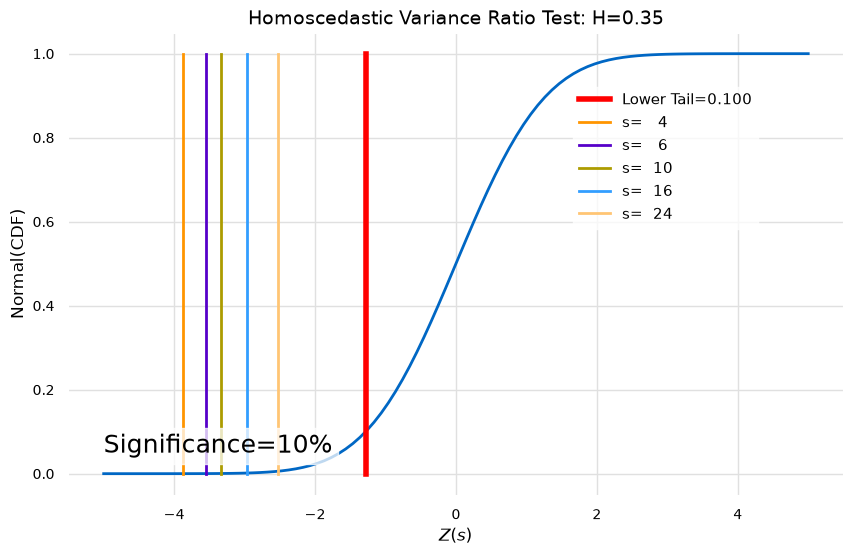

In [238]:
homo_test_stat_plot(result, H)

In [239]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.872 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -3.554 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.334 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.96  │    0.998 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2.528 │    0.994 │ Pas

In [240]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "c1cff451-6efa-43ed-8a64-6f6bdfbee9bb",
                "label": "$Z(s)$",
                "value": -3.872470128221268
            },
            "pval": {
                "test_id": "c1cff451-6efa-43ed-8a64-6f6bdfbee9bb",
                "label": "$p-value$",
                "value": 0.9999461310581201
            },
            "params": [
                {
                    "test_id": "c1cff451-6efa-43ed-8a64-6f6bdfbee9bb",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "c1cff451-6efa-43ed-8a64-6f6bdfbee9bb",
                "label": "10%",
                "value": 0.1
            },
            "lower": null,
            "upper": {
                "test_id": "c1cff451-6efa-43ed-8a64-6

In [241]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.872 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -3.554 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.334 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.96  │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2

In [242]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "aa1d916a-d56c-4ba9-9673-1a7a2fe2471b",
                "label": "$Z(s)$",
                "value": -3.872470128221268
            },
            "pval": {
                "test_id": "aa1d916a-d56c-4ba9-9673-1a7a2fe2471b",
                "label": "$p-value$",
                "value": 0.0001077378837597287
            },
            "params": [
                {
                    "test_id": "aa1d916a-d56c-4ba9-9673-1a7a2fe2471b",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "aa1d916a-d56c-4ba9-9673-1a7a2fe2471b",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "aa1d916a-d56c-4ba9-9673-1a7a2fe2471b",
                "la

### $H = 0.6$

Here an upper tailed test for fractional brownian motion with $H > \frac{1}{2}$. The test is successful if the result is **Failed**.

In [243]:
H=0.6
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  4.088 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  3.96  │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.619 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  2.722 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  2.203 │    0.014 │ Fai

In [244]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "7bbf9590-4fe0-484b-ab85-18e1db45c25f",
                "label": "$Z(s)$",
                "value": 4.087571716313736
            },
            "pval": {
                "test_id": "7bbf9590-4fe0-484b-ab85-18e1db45c25f",
                "label": "$p-value$",
                "value": 2.1795597185625404e-05
            },
            "params": [
                {
                    "test_id": "7bbf9590-4fe0-484b-ab85-18e1db45c25f",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "7bbf9590-4fe0-484b-ab85-18e1db45c25f",
                "label": "10%",
                "value": 0.1
            },
            "lower": null,
            "upper": {
                "test_id": "7bbf9590-4fe0-484b-ab8

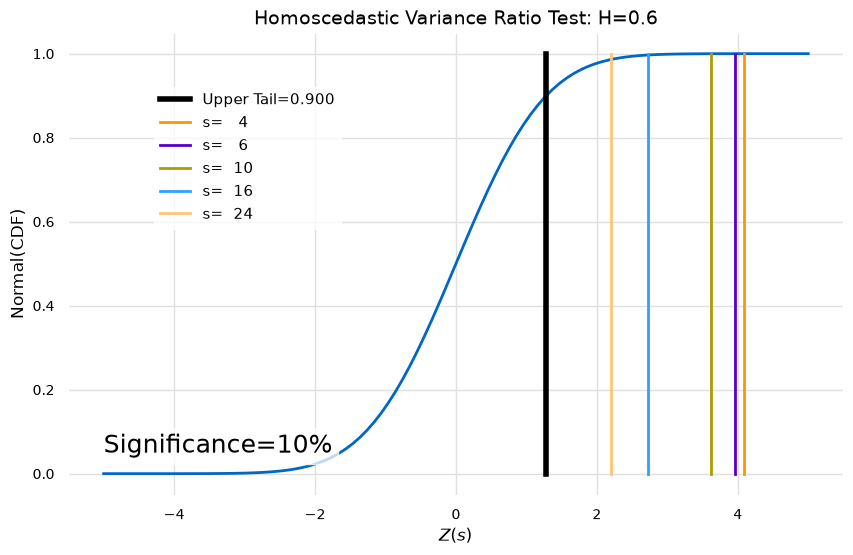

In [245]:
homo_test_stat_plot(result, H)

In [246]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  4.088 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  3.96  │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.619 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  2.722 │    0.997 │ Passed   │
├─────┼────────┼──────────┼───────

In [247]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "fc8878ad-8f5d-4698-a805-c0262ce77633",
                "label": "$Z(s)$",
                "value": 4.087571716313736
            },
            "pval": {
                "test_id": "fc8878ad-8f5d-4698-a805-c0262ce77633",
                "label": "$p-value$",
                "value": 0.9999782044028144
            },
            "params": [
                {
                    "test_id": "fc8878ad-8f5d-4698-a805-c0262ce77633",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "fc8878ad-8f5d-4698-a805-c0262ce77633",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "fc8878ad-8f5d-4698-a805-c0262ce77633",
          

In [248]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  4.088 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  3.96  │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.619 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  2.722 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  2

In [249]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "5b7ccb8a-d2ab-4c8e-9ae2-0013e1e8a14d",
                "label": "$Z(s)$",
                "value": 4.087571716313736
            },
            "pval": {
                "test_id": "5b7ccb8a-d2ab-4c8e-9ae2-0013e1e8a14d",
                "label": "$p-value$",
                "value": 4.359119437125081e-05
            },
            "params": [
                {
                    "test_id": "5b7ccb8a-d2ab-4c8e-9ae2-0013e1e8a14d",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "5b7ccb8a-d2ab-4c8e-9ae2-0013e1e8a14d",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "5b7ccb8a-d2ab-4c8e-9ae2-0013e1e8a14d",
                "lab